In [1]:
#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Set random seed for reproducibility
#manualSeed = 999
#manualSeed = random.randint(1, 10000) # use if you want new results
#print("Random Seed: ", manualSeed)
#random.seed(manualSeed)
#torch.manual_seed(manualSeed)
#torch.use_deterministic_algorithms(True) # Needed for reproducible results

In [2]:
# Root directory for dataset
dataroot = "train"

# Number of channels in the training images. For color images this is 3
nc = 3

# Size of z latent vector (i.e. size of generator input)
nz = 128

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

# Create Datasets

In [3]:
import os
import random
import numpy as np
import cv2
import torch
from torch.utils.data import DataLoader
from torchvision import datasets as dset, transforms
import torchvision.transforms.functional as TF
from PIL import Image, ImageOps


class ResizePadToWidth:
    def __init__(self, target_height=80, target_width=512, grayscale=True, pad_color=255, augment=False):
        self.target_height = target_height
        self.target_width = target_width
        self.grayscale = grayscale
        self.pad_color = pad_color
        self.augment = augment

    def __call__(self, img):
        # If img is PIL.Image, convert to OpenCV NumPy array
        if isinstance(img, Image.Image):
            img = np.array(img)  # H x W x C or H x W
            # Convert RGB to BGR for OpenCV (optional, since we're just resizing/padding)
            if not self.grayscale and img.ndim == 3:
                img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        H, W = img.shape[:2]

        # --- Resize keeping aspect ratio ---
        if H != self.target_height:
            new_W = int(W * (self.target_height / float(H)))
            img = cv2.resize(img, (new_W, self.target_height), interpolation=cv2.INTER_AREA)
            H, W = img.shape[:2]

        # --- Crop if too wide ---
        if W > self.target_width:
            if self.augment:
                left = random.randint(0, W - self.target_width)
            else:
                left = (W - self.target_width) // 2
            img = img[:, left:left + self.target_width]
            W = self.target_width

        # --- Pad if too narrow ---
        pad_left = (self.target_width - W) // 2
        pad_right = self.target_width - W - pad_left
        if self.augment and self.target_width - W > 0:
            shift = random.randint(-int(0.15 * (self.target_width - W)), int(0.15 * (self.target_width - W)))
            pad_left = max(0, min(self.target_width - W, pad_left + shift))
            pad_right = self.target_width - W - pad_left

        if self.grayscale:
            if img.ndim == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.copyMakeBorder(img, 0, 0, pad_left, pad_right, borderType=cv2.BORDER_CONSTANT, value=self.pad_color)
        else:
            if img.ndim == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            img = cv2.copyMakeBorder(img, 0, 0, pad_left, pad_right, borderType=cv2.BORDER_CONSTANT, value=[self.pad_color]*3)

        # --- To Tensor in [-1,1] ---
        img = img.astype(np.float32) / 255.0
        img = (img - 0.5) / 0.5

        if self.grayscale:
            tensor = torch.from_numpy(img).unsqueeze(0)  # [1,H,W]
        else:
            tensor = torch.from_numpy(np.transpose(img, (2,0,1)))  # [3,H,W]

        return tensor


In [4]:
# We can use an image folder dataset the way we have it setup.
# Create the dataset
dataset = dset.ImageFolder(
    root=dataroot,
    transform=ResizePadToWidth(target_height=40,
                                  target_width=256,
                                  grayscale=False,   # change to False for RGB
                                  pad_color=255,    # white padding
                                  augment=True)
)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)


# Prepare GPU

In [5]:
# Decide which device we want to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print(device)

cuda:0


# View Dataset

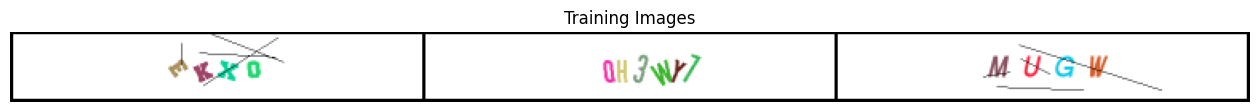

In [6]:
# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(16,16))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:3], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

# Weight Init

In [7]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Generator

In [8]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, nz=128, ngf=64, nc=3):
        super().__init__()

        self.main = nn.Sequential(
            # 1x1 → 5x16
            nn.ConvTranspose2d(nz, ngf*16, kernel_size=(5,16), stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf*16),
            nn.ReLU(True),

            # 5x16 → 10x32
            nn.ConvTranspose2d(ngf*16, ngf*8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            # 10x32 → 20x64
            nn.ConvTranspose2d(ngf*8, ngf*4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            # 20x64 → 40x128
            nn.ConvTranspose2d(ngf*4, ngf*2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            # 40x128 → 40x256 (double width only)
            nn.ConvTranspose2d(ngf*2, ngf, kernel_size=(3,4), stride=(1,2), padding=(1,1), bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # final: 40×256 → output RGB
            nn.ConvTranspose2d(ngf, nc, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)

In [9]:
# Create the generator
netG = Generator().to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(128, 1024, kernel_size=(5, 16), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 64, kernel_size=(3, 4), stride=(1, 2), padding=(1, 1), bias=False)
    (13): Batch

# Discriminator

In [10]:
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            # 40x256 → 20x128
            nn.Conv2d(nc, ndf, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 20x128 → 10x64
            nn.Conv2d(ndf, ndf*2, 4, 2, 1),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            # 10x64 → 5x32
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            # 5x32 → 1x1
            nn.Conv2d(ndf*4, 1, kernel_size=(5,32), stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)  # [batch]

In [11]:
# Create the Discriminator
netD = Discriminator().to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)

# Print the model
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(5, 32), stride=(1, 1))
    (9): Sigmoid()
  )
)


# Training

In [12]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1.0
fake_label = 0.0

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0001, betas=(0.5, 0.999))

Starting Training Loop...
[0/200][0/157]	Loss_D: 1.5550	Loss_G: 0.0187	D(x): 0.5322	D(G(z)): 0.3216 / 0.9832
[0/200][50/157]	Loss_D: 3.2770	Loss_G: 0.9598	D(x): 0.4154	D(G(z)): 0.0299 / 0.4703
[0/200][100/157]	Loss_D: 3.0552	Loss_G: 3.8371	D(x): 0.6520	D(G(z)): 0.8661 / 0.0593
[0/200][150/157]	Loss_D: 2.7842	Loss_G: 1.8395	D(x): 0.7006	D(G(z)): 0.7807 / 0.2255


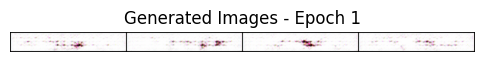

[1/200][0/157]	Loss_D: 3.4484	Loss_G: 0.0926	D(x): 0.1057	D(G(z)): 0.1722 / 0.9155
[1/200][50/157]	Loss_D: 3.8089	Loss_G: 0.1415	D(x): 0.1026	D(G(z)): 0.4972 / 0.8719
[1/200][100/157]	Loss_D: 2.7320	Loss_G: 1.6201	D(x): 0.6520	D(G(z)): 0.8487 / 0.2512
[1/200][150/157]	Loss_D: 3.0876	Loss_G: 1.3629	D(x): 0.6447	D(G(z)): 0.9063 / 0.2816


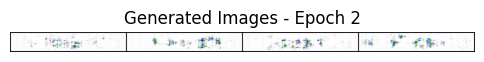

[2/200][0/157]	Loss_D: 2.9385	Loss_G: 0.1026	D(x): 0.0876	D(G(z)): 0.1647 / 0.9049
[2/200][50/157]	Loss_D: 3.2188	Loss_G: 1.7390	D(x): 0.8222	D(G(z)): 0.9416 / 0.2069
[2/200][100/157]	Loss_D: 2.7717	Loss_G: 1.3731	D(x): 0.6953	D(G(z)): 0.8814 / 0.2949
[2/200][150/157]	Loss_D: 2.6022	Loss_G: 0.2261	D(x): 0.1228	D(G(z)): 0.2329 / 0.8015


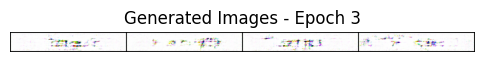

[3/200][0/157]	Loss_D: 2.7375	Loss_G: 1.9601	D(x): 0.8226	D(G(z)): 0.9113 / 0.1667
[3/200][50/157]	Loss_D: 1.9530	Loss_G: 0.9006	D(x): 0.4739	D(G(z)): 0.6352 / 0.4365
[3/200][100/157]	Loss_D: 2.2933	Loss_G: 1.1392	D(x): 0.5342	D(G(z)): 0.7799 / 0.3478
[3/200][150/157]	Loss_D: 1.8854	Loss_G: 0.5990	D(x): 0.3925	D(G(z)): 0.5556 / 0.5642


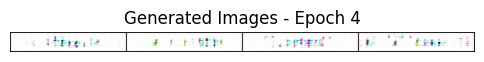

[4/200][0/157]	Loss_D: 2.2857	Loss_G: 1.7430	D(x): 0.7098	D(G(z)): 0.8421 / 0.1878
[4/200][50/157]	Loss_D: 1.7402	Loss_G: 0.7027	D(x): 0.4450	D(G(z)): 0.5378 / 0.5064
[4/200][100/157]	Loss_D: 1.9839	Loss_G: 0.2987	D(x): 0.2345	D(G(z)): 0.3378 / 0.7483
[4/200][150/157]	Loss_D: 2.1791	Loss_G: 0.2066	D(x): 0.1723	D(G(z)): 0.2705 / 0.8165


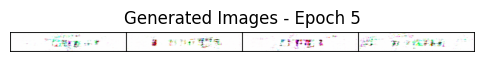

[5/200][0/157]	Loss_D: 1.8631	Loss_G: 0.9466	D(x): 0.5863	D(G(z)): 0.7100 / 0.4035
[5/200][50/157]	Loss_D: 1.7024	Loss_G: 0.4745	D(x): 0.3696	D(G(z)): 0.4613 / 0.6302
[5/200][100/157]	Loss_D: 1.5393	Loss_G: 0.5899	D(x): 0.4211	D(G(z)): 0.4432 / 0.5681
[5/200][150/157]	Loss_D: 1.7560	Loss_G: 0.9432	D(x): 0.6227	D(G(z)): 0.6975 / 0.4012


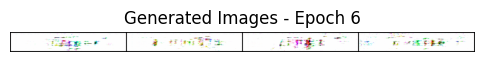

[6/200][0/157]	Loss_D: 1.9611	Loss_G: 0.2794	D(x): 0.1805	D(G(z)): 0.1505 / 0.7611
[6/200][50/157]	Loss_D: 1.8026	Loss_G: 0.2309	D(x): 0.2233	D(G(z)): 0.2061 / 0.7965
[6/200][100/157]	Loss_D: 1.4809	Loss_G: 0.7160	D(x): 0.5103	D(G(z)): 0.5271 / 0.5014
[6/200][150/157]	Loss_D: 1.3842	Loss_G: 0.7528	D(x): 0.4937	D(G(z)): 0.4569 / 0.4832


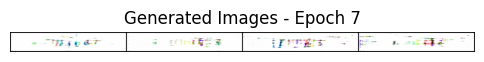

[7/200][0/157]	Loss_D: 1.6598	Loss_G: 0.2590	D(x): 0.2711	D(G(z)): 0.2317 / 0.7746
[7/200][50/157]	Loss_D: 1.4989	Loss_G: 0.5174	D(x): 0.3898	D(G(z)): 0.3895 / 0.6043
[7/200][100/157]	Loss_D: 1.6197	Loss_G: 1.3395	D(x): 0.7385	D(G(z)): 0.7190 / 0.2772
[7/200][150/157]	Loss_D: 1.6074	Loss_G: 0.3344	D(x): 0.2795	D(G(z)): 0.2359 / 0.7200


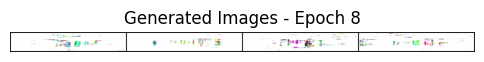

[8/200][0/157]	Loss_D: 1.6771	Loss_G: 1.3462	D(x): 0.7342	D(G(z)): 0.7288 / 0.2701
[8/200][50/157]	Loss_D: 1.3968	Loss_G: 1.0009	D(x): 0.5391	D(G(z)): 0.5240 / 0.3799
[8/200][100/157]	Loss_D: 1.4514	Loss_G: 0.5398	D(x): 0.3907	D(G(z)): 0.3750 / 0.5889
[8/200][150/157]	Loss_D: 1.5614	Loss_G: 0.6442	D(x): 0.5480	D(G(z)): 0.6010 / 0.5327


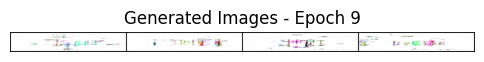

[9/200][0/157]	Loss_D: 1.3603	Loss_G: 0.7521	D(x): 0.5770	D(G(z)): 0.5369 / 0.4847
[9/200][50/157]	Loss_D: 1.8178	Loss_G: 0.3021	D(x): 0.2194	D(G(z)): 0.2105 / 0.7440
[9/200][100/157]	Loss_D: 1.7192	Loss_G: 1.1952	D(x): 0.7109	D(G(z)): 0.7374 / 0.3157
[9/200][150/157]	Loss_D: 1.7688	Loss_G: 1.4449	D(x): 0.7884	D(G(z)): 0.7744 / 0.2413


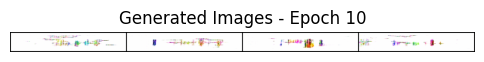

[10/200][0/157]	Loss_D: 1.4888	Loss_G: 0.4732	D(x): 0.3432	D(G(z)): 0.3198 / 0.6287
[10/200][50/157]	Loss_D: 1.4953	Loss_G: 1.1278	D(x): 0.6777	D(G(z)): 0.6562 / 0.3317
[10/200][100/157]	Loss_D: 1.4779	Loss_G: 1.3302	D(x): 0.7183	D(G(z)): 0.6671 / 0.2769
[10/200][150/157]	Loss_D: 1.5351	Loss_G: 1.2480	D(x): 0.7051	D(G(z)): 0.6843 / 0.2939


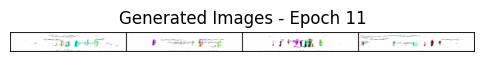

[11/200][0/157]	Loss_D: 1.3026	Loss_G: 0.8727	D(x): 0.5427	D(G(z)): 0.4827 / 0.4271
[11/200][50/157]	Loss_D: 1.8318	Loss_G: 1.5422	D(x): 0.6360	D(G(z)): 0.7311 / 0.2198
[11/200][100/157]	Loss_D: 1.4121	Loss_G: 0.4595	D(x): 0.3436	D(G(z)): 0.2540 / 0.6363
[11/200][150/157]	Loss_D: 1.8418	Loss_G: 0.2839	D(x): 0.2290	D(G(z)): 0.2428 / 0.7559


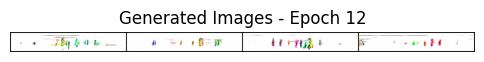

[12/200][0/157]	Loss_D: 1.2690	Loss_G: 1.4530	D(x): 0.7620	D(G(z)): 0.6193 / 0.2448
[12/200][50/157]	Loss_D: 1.2777	Loss_G: 0.7797	D(x): 0.4309	D(G(z)): 0.3302 / 0.4702
[12/200][100/157]	Loss_D: 1.3619	Loss_G: 0.8044	D(x): 0.5255	D(G(z)): 0.4968 / 0.4548
[12/200][150/157]	Loss_D: 1.4155	Loss_G: 0.8184	D(x): 0.5377	D(G(z)): 0.5349 / 0.4477


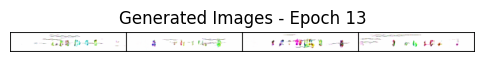

[13/200][0/157]	Loss_D: 1.3445	Loss_G: 0.7578	D(x): 0.5232	D(G(z)): 0.4763 / 0.4782
[13/200][50/157]	Loss_D: 1.5087	Loss_G: 1.5480	D(x): 0.8480	D(G(z)): 0.7259 / 0.2221
[13/200][100/157]	Loss_D: 1.6560	Loss_G: 1.3865	D(x): 0.6400	D(G(z)): 0.6878 / 0.2571
[13/200][150/157]	Loss_D: 1.7387	Loss_G: 1.4072	D(x): 0.6927	D(G(z)): 0.7387 / 0.2508


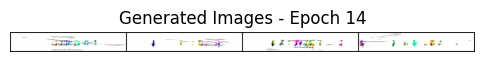

[14/200][0/157]	Loss_D: 1.4245	Loss_G: 0.4738	D(x): 0.3856	D(G(z)): 0.3526 / 0.6270
[14/200][50/157]	Loss_D: 1.5427	Loss_G: 0.4547	D(x): 0.3329	D(G(z)): 0.3302 / 0.6396
[14/200][100/157]	Loss_D: 1.3402	Loss_G: 0.8289	D(x): 0.5270	D(G(z)): 0.4900 / 0.4421
[14/200][150/157]	Loss_D: 1.3645	Loss_G: 1.2220	D(x): 0.6915	D(G(z)): 0.6213 / 0.3038


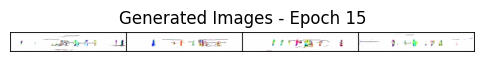

[15/200][0/157]	Loss_D: 1.3613	Loss_G: 0.5138	D(x): 0.4269	D(G(z)): 0.3799 / 0.6031
[15/200][50/157]	Loss_D: 1.3428	Loss_G: 0.7816	D(x): 0.5069	D(G(z)): 0.4738 / 0.4628
[15/200][100/157]	Loss_D: 1.4420	Loss_G: 0.5960	D(x): 0.4838	D(G(z)): 0.4966 / 0.5564
[15/200][150/157]	Loss_D: 1.4594	Loss_G: 1.3178	D(x): 0.6398	D(G(z)): 0.6245 / 0.2742


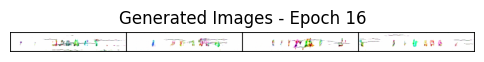

[16/200][0/157]	Loss_D: 1.3693	Loss_G: 0.7194	D(x): 0.4628	D(G(z)): 0.4416 / 0.4924
[16/200][50/157]	Loss_D: 1.7484	Loss_G: 1.6729	D(x): 0.8027	D(G(z)): 0.7766 / 0.1947
[16/200][100/157]	Loss_D: 1.3938	Loss_G: 0.5669	D(x): 0.4404	D(G(z)): 0.4246 / 0.5725
[16/200][150/157]	Loss_D: 1.5256	Loss_G: 0.4099	D(x): 0.2903	D(G(z)): 0.2331 / 0.6676


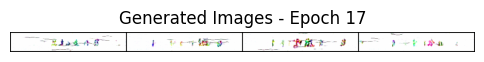

[17/200][0/157]	Loss_D: 1.4598	Loss_G: 1.0861	D(x): 0.6288	D(G(z)): 0.6196 / 0.3442
[17/200][50/157]	Loss_D: 1.3706	Loss_G: 0.7037	D(x): 0.4756	D(G(z)): 0.4515 / 0.5013
[17/200][100/157]	Loss_D: 1.4983	Loss_G: 1.6588	D(x): 0.7014	D(G(z)): 0.6739 / 0.1959
[17/200][150/157]	Loss_D: 1.5056	Loss_G: 0.3449	D(x): 0.3520	D(G(z)): 0.3563 / 0.7115


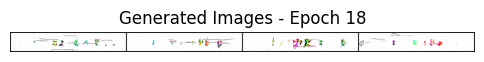

[18/200][0/157]	Loss_D: 1.4694	Loss_G: 1.0539	D(x): 0.6855	D(G(z)): 0.6559 / 0.3541
[18/200][50/157]	Loss_D: 1.3497	Loss_G: 0.6914	D(x): 0.4750	D(G(z)): 0.4437 / 0.5039
[18/200][100/157]	Loss_D: 1.4250	Loss_G: 0.4917	D(x): 0.3682	D(G(z)): 0.3374 / 0.6144
[18/200][150/157]	Loss_D: 1.3611	Loss_G: 0.9764	D(x): 0.6073	D(G(z)): 0.5675 / 0.3826


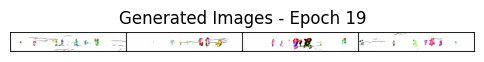

[19/200][0/157]	Loss_D: 1.3708	Loss_G: 0.5925	D(x): 0.4238	D(G(z)): 0.3872 / 0.5570
[19/200][50/157]	Loss_D: 1.3993	Loss_G: 0.7235	D(x): 0.4457	D(G(z)): 0.4278 / 0.4913
[19/200][100/157]	Loss_D: 1.5366	Loss_G: 0.4226	D(x): 0.3168	D(G(z)): 0.3096 / 0.6582
[19/200][150/157]	Loss_D: 1.5504	Loss_G: 1.3461	D(x): 0.6813	D(G(z)): 0.6791 / 0.2648


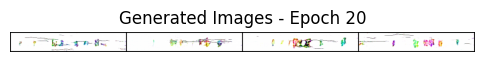

[20/200][0/157]	Loss_D: 1.3632	Loss_G: 0.7144	D(x): 0.4897	D(G(z)): 0.4643 / 0.4933
[20/200][50/157]	Loss_D: 1.3774	Loss_G: 0.5646	D(x): 0.4208	D(G(z)): 0.3845 / 0.5744
[20/200][100/157]	Loss_D: 1.4579	Loss_G: 0.8333	D(x): 0.6155	D(G(z)): 0.6146 / 0.4409
[20/200][150/157]	Loss_D: 1.3732	Loss_G: 0.6373	D(x): 0.4561	D(G(z)): 0.4316 / 0.5330


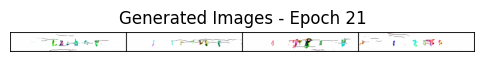

[21/200][0/157]	Loss_D: 1.7494	Loss_G: 1.5677	D(x): 0.7931	D(G(z)): 0.7737 / 0.2158
[21/200][50/157]	Loss_D: 1.3838	Loss_G: 0.6727	D(x): 0.4661	D(G(z)): 0.4496 / 0.5145
[21/200][100/157]	Loss_D: 1.3552	Loss_G: 0.6622	D(x): 0.4843	D(G(z)): 0.4557 / 0.5212
[21/200][150/157]	Loss_D: 1.4174	Loss_G: 1.0771	D(x): 0.6414	D(G(z)): 0.6139 / 0.3472


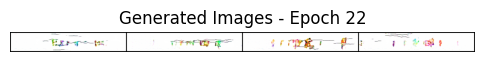

[22/200][0/157]	Loss_D: 1.3514	Loss_G: 0.5905	D(x): 0.4414	D(G(z)): 0.4003 / 0.5584
[22/200][50/157]	Loss_D: 1.4123	Loss_G: 0.8989	D(x): 0.6352	D(G(z)): 0.6086 / 0.4129
[22/200][100/157]	Loss_D: 1.4244	Loss_G: 0.9726	D(x): 0.6211	D(G(z)): 0.6065 / 0.3816
[22/200][150/157]	Loss_D: 1.5131	Loss_G: 0.9988	D(x): 0.6196	D(G(z)): 0.6358 / 0.3725


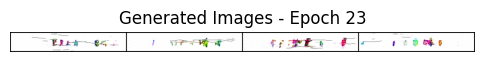

[23/200][0/157]	Loss_D: 1.5337	Loss_G: 0.3834	D(x): 0.2867	D(G(z)): 0.2306 / 0.6846
[23/200][50/157]	Loss_D: 1.3948	Loss_G: 0.7653	D(x): 0.5300	D(G(z)): 0.5218 / 0.4707
[23/200][100/157]	Loss_D: 1.3669	Loss_G: 0.7803	D(x): 0.5085	D(G(z)): 0.4904 / 0.4619
[23/200][150/157]	Loss_D: 1.3749	Loss_G: 1.0455	D(x): 0.5829	D(G(z)): 0.5571 / 0.3579


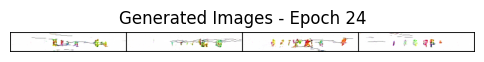

[24/200][0/157]	Loss_D: 1.4138	Loss_G: 0.5150	D(x): 0.3808	D(G(z)): 0.3448 / 0.6017
[24/200][50/157]	Loss_D: 1.3449	Loss_G: 0.5437	D(x): 0.4363	D(G(z)): 0.3947 / 0.5839
[24/200][100/157]	Loss_D: 1.4632	Loss_G: 0.3248	D(x): 0.3253	D(G(z)): 0.2771 / 0.7245
[24/200][150/157]	Loss_D: 1.4848	Loss_G: 1.0347	D(x): 0.6572	D(G(z)): 0.6475 / 0.3597


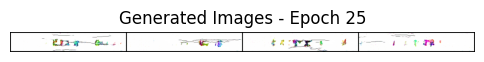

[25/200][0/157]	Loss_D: 1.4404	Loss_G: 0.4576	D(x): 0.3610	D(G(z)): 0.3313 / 0.6350
[25/200][50/157]	Loss_D: 1.5996	Loss_G: 0.2699	D(x): 0.2667	D(G(z)): 0.2205 / 0.7648
[25/200][100/157]	Loss_D: 1.5315	Loss_G: 0.3358	D(x): 0.3115	D(G(z)): 0.2885 / 0.7172
[25/200][150/157]	Loss_D: 1.4109	Loss_G: 1.1785	D(x): 0.7118	D(G(z)): 0.6510 / 0.3107


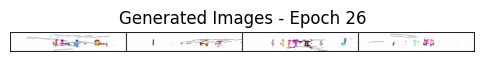

[26/200][0/157]	Loss_D: 1.3428	Loss_G: 0.6322	D(x): 0.4530	D(G(z)): 0.4139 / 0.5361
[26/200][50/157]	Loss_D: 1.3715	Loss_G: 0.8505	D(x): 0.5539	D(G(z)): 0.5336 / 0.4333
[26/200][100/157]	Loss_D: 1.5871	Loss_G: 1.1182	D(x): 0.6008	D(G(z)): 0.6506 / 0.3336
[26/200][150/157]	Loss_D: 1.3292	Loss_G: 0.5927	D(x): 0.4624	D(G(z)): 0.4145 / 0.5565


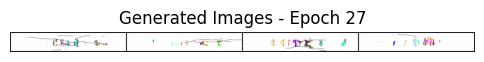

[27/200][0/157]	Loss_D: 1.3641	Loss_G: 0.8383	D(x): 0.5589	D(G(z)): 0.5337 / 0.4368
[27/200][50/157]	Loss_D: 1.3939	Loss_G: 0.6364	D(x): 0.4086	D(G(z)): 0.3784 / 0.5322
[27/200][100/157]	Loss_D: 1.3818	Loss_G: 0.8197	D(x): 0.5142	D(G(z)): 0.4982 / 0.4460
[27/200][150/157]	Loss_D: 1.4354	Loss_G: 0.4951	D(x): 0.3709	D(G(z)): 0.3446 / 0.6157


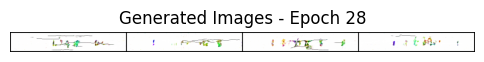

[28/200][0/157]	Loss_D: 1.5839	Loss_G: 1.5457	D(x): 0.7510	D(G(z)): 0.7218 / 0.2184
[28/200][50/157]	Loss_D: 1.4441	Loss_G: 0.4591	D(x): 0.3647	D(G(z)): 0.3395 / 0.6358
[28/200][100/157]	Loss_D: 1.4191	Loss_G: 0.4682	D(x): 0.3859	D(G(z)): 0.3545 / 0.6283
[28/200][150/157]	Loss_D: 1.3482	Loss_G: 0.9399	D(x): 0.5640	D(G(z)): 0.5292 / 0.3951


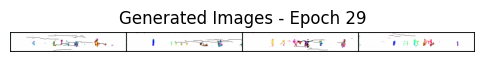

[29/200][0/157]	Loss_D: 1.3694	Loss_G: 0.5526	D(x): 0.3772	D(G(z)): 0.3072 / 0.5805
[29/200][50/157]	Loss_D: 1.4470	Loss_G: 0.6354	D(x): 0.4297	D(G(z)): 0.4319 / 0.5360
[29/200][100/157]	Loss_D: 1.4070	Loss_G: 1.0979	D(x): 0.6535	D(G(z)): 0.6165 / 0.3373
[29/200][150/157]	Loss_D: 1.4469	Loss_G: 1.2693	D(x): 0.6569	D(G(z)): 0.6342 / 0.2885


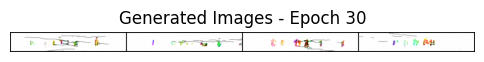

[30/200][0/157]	Loss_D: 1.3731	Loss_G: 0.6020	D(x): 0.4039	D(G(z)): 0.3540 / 0.5502
[30/200][50/157]	Loss_D: 1.4597	Loss_G: 1.2542	D(x): 0.6589	D(G(z)): 0.6399 / 0.2903
[30/200][100/157]	Loss_D: 1.3979	Loss_G: 1.0691	D(x): 0.5970	D(G(z)): 0.5772 / 0.3488
[30/200][150/157]	Loss_D: 1.3888	Loss_G: 0.9946	D(x): 0.6337	D(G(z)): 0.5977 / 0.3735


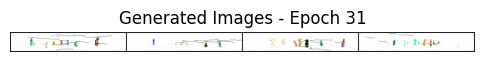

[31/200][0/157]	Loss_D: 1.4461	Loss_G: 0.4144	D(x): 0.3794	D(G(z)): 0.3608 / 0.6634
[31/200][50/157]	Loss_D: 1.5467	Loss_G: 1.2614	D(x): 0.7306	D(G(z)): 0.7015 / 0.2873
[31/200][100/157]	Loss_D: 1.3989	Loss_G: 0.5282	D(x): 0.4016	D(G(z)): 0.3683 / 0.5944
[31/200][150/157]	Loss_D: 1.3560	Loss_G: 0.6235	D(x): 0.4218	D(G(z)): 0.3727 / 0.5420


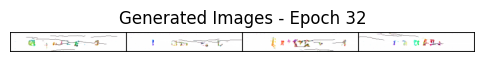

[32/200][0/157]	Loss_D: 1.5530	Loss_G: 1.7186	D(x): 0.7582	D(G(z)): 0.7126 / 0.1863
[32/200][50/157]	Loss_D: 1.3883	Loss_G: 0.6275	D(x): 0.4344	D(G(z)): 0.4144 / 0.5390
[32/200][100/157]	Loss_D: 1.3135	Loss_G: 0.7494	D(x): 0.5199	D(G(z)): 0.4670 / 0.4780
[32/200][150/157]	Loss_D: 1.4560	Loss_G: 1.1838	D(x): 0.6892	D(G(z)): 0.6525 / 0.3119


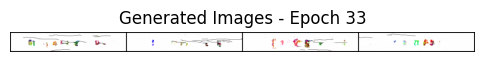

[33/200][0/157]	Loss_D: 1.2910	Loss_G: 0.5261	D(x): 0.4198	D(G(z)): 0.3348 / 0.5943
[33/200][50/157]	Loss_D: 1.4354	Loss_G: 0.4598	D(x): 0.3669	D(G(z)): 0.3300 / 0.6342
[33/200][100/157]	Loss_D: 1.4100	Loss_G: 1.0155	D(x): 0.6824	D(G(z)): 0.6352 / 0.3672
[33/200][150/157]	Loss_D: 1.2999	Loss_G: 0.5972	D(x): 0.4680	D(G(z)): 0.4053 / 0.5543


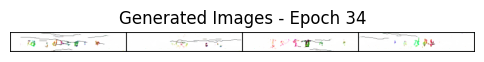

[34/200][0/157]	Loss_D: 1.6500	Loss_G: 1.7795	D(x): 0.7868	D(G(z)): 0.7493 / 0.1727
[34/200][50/157]	Loss_D: 1.2997	Loss_G: 0.6173	D(x): 0.4839	D(G(z)): 0.4242 / 0.5421
[34/200][100/157]	Loss_D: 1.6033	Loss_G: 0.4499	D(x): 0.2732	D(G(z)): 0.2291 / 0.6421
[34/200][150/157]	Loss_D: 1.3190	Loss_G: 1.1433	D(x): 0.6395	D(G(z)): 0.5740 / 0.3232


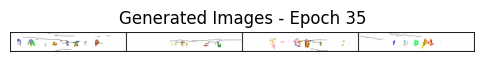

[35/200][0/157]	Loss_D: 1.4022	Loss_G: 0.4846	D(x): 0.3603	D(G(z)): 0.2906 / 0.6209
[35/200][50/157]	Loss_D: 1.3698	Loss_G: 1.1078	D(x): 0.6711	D(G(z)): 0.6103 / 0.3375
[35/200][100/157]	Loss_D: 1.3344	Loss_G: 0.9610	D(x): 0.6344	D(G(z)): 0.5761 / 0.3862
[35/200][150/157]	Loss_D: 1.2986	Loss_G: 0.6272	D(x): 0.4548	D(G(z)): 0.3830 / 0.5372


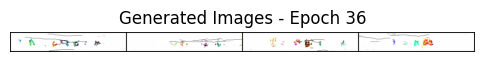

[36/200][0/157]	Loss_D: 1.5618	Loss_G: 1.5441	D(x): 0.7597	D(G(z)): 0.7163 / 0.2180
[36/200][50/157]	Loss_D: 1.3561	Loss_G: 1.1127	D(x): 0.6444	D(G(z)): 0.5836 / 0.3359
[36/200][100/157]	Loss_D: 1.2887	Loss_G: 0.8321	D(x): 0.5474	D(G(z)): 0.4835 / 0.4403
[36/200][150/157]	Loss_D: 1.6380	Loss_G: 0.3495	D(x): 0.2539	D(G(z)): 0.2089 / 0.7085


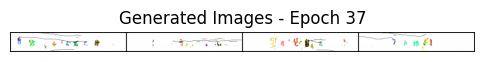

[37/200][0/157]	Loss_D: 1.3700	Loss_G: 1.3951	D(x): 0.7078	D(G(z)): 0.6282 / 0.2547
[37/200][50/157]	Loss_D: 1.2778	Loss_G: 0.8158	D(x): 0.5323	D(G(z)): 0.4614 / 0.4517
[37/200][100/157]	Loss_D: 1.2594	Loss_G: 0.8651	D(x): 0.5667	D(G(z)): 0.4860 / 0.4258
[37/200][150/157]	Loss_D: 1.2874	Loss_G: 0.6475	D(x): 0.4885	D(G(z)): 0.4154 / 0.5286


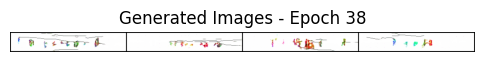

[38/200][0/157]	Loss_D: 1.3923	Loss_G: 1.1601	D(x): 0.6942	D(G(z)): 0.6328 / 0.3216
[38/200][50/157]	Loss_D: 1.2513	Loss_G: 0.5151	D(x): 0.4913	D(G(z)): 0.3966 / 0.6026
[38/200][100/157]	Loss_D: 1.2891	Loss_G: 1.1687	D(x): 0.6753	D(G(z)): 0.5812 / 0.3196
[38/200][150/157]	Loss_D: 1.3430	Loss_G: 1.1701	D(x): 0.6606	D(G(z)): 0.5934 / 0.3187


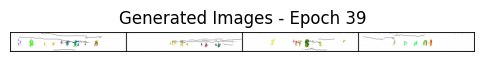

[39/200][0/157]	Loss_D: 1.4640	Loss_G: 1.5209	D(x): 0.7560	D(G(z)): 0.6858 / 0.2228
[39/200][50/157]	Loss_D: 1.2723	Loss_G: 1.2322	D(x): 0.7305	D(G(z)): 0.6079 / 0.3007
[39/200][100/157]	Loss_D: 1.3370	Loss_G: 1.2515	D(x): 0.6817	D(G(z)): 0.5978 / 0.2953
[39/200][150/157]	Loss_D: 1.3835	Loss_G: 0.4606	D(x): 0.3741	D(G(z)): 0.3058 / 0.6366


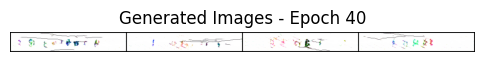

[40/200][0/157]	Loss_D: 1.2436	Loss_G: 0.7826	D(x): 0.5672	D(G(z)): 0.4703 / 0.4631
[40/200][50/157]	Loss_D: 1.2795	Loss_G: 0.5674	D(x): 0.4503	D(G(z)): 0.3635 / 0.5718
[40/200][100/157]	Loss_D: 1.3291	Loss_G: 0.9066	D(x): 0.5958	D(G(z)): 0.5382 / 0.4128
[40/200][150/157]	Loss_D: 1.2735	Loss_G: 1.3507	D(x): 0.6554	D(G(z)): 0.5602 / 0.2714


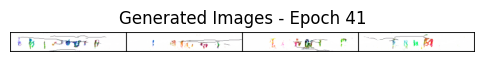

[41/200][0/157]	Loss_D: 1.4468	Loss_G: 0.4481	D(x): 0.3144	D(G(z)): 0.2031 / 0.6444
[41/200][50/157]	Loss_D: 1.3078	Loss_G: 0.6082	D(x): 0.4323	D(G(z)): 0.3504 / 0.5519
[41/200][100/157]	Loss_D: 1.4482	Loss_G: 0.5094	D(x): 0.3488	D(G(z)): 0.3028 / 0.6060
[41/200][150/157]	Loss_D: 1.3895	Loss_G: 1.3233	D(x): 0.6948	D(G(z)): 0.6295 / 0.2794


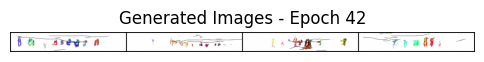

[42/200][0/157]	Loss_D: 1.1678	Loss_G: 0.7817	D(x): 0.5189	D(G(z)): 0.3840 / 0.4695
[42/200][50/157]	Loss_D: 1.3885	Loss_G: 0.4980	D(x): 0.3475	D(G(z)): 0.2615 / 0.6181
[42/200][100/157]	Loss_D: 1.2951	Loss_G: 0.8659	D(x): 0.6244	D(G(z)): 0.5519 / 0.4253
[42/200][150/157]	Loss_D: 1.4200	Loss_G: 0.5133	D(x): 0.3844	D(G(z)): 0.3390 / 0.6051


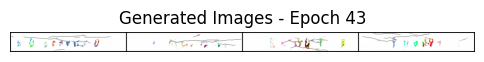

[43/200][0/157]	Loss_D: 1.2043	Loss_G: 0.7073	D(x): 0.5348	D(G(z)): 0.4273 / 0.5051
[43/200][50/157]	Loss_D: 1.2525	Loss_G: 0.9691	D(x): 0.6125	D(G(z)): 0.5203 / 0.3859
[43/200][100/157]	Loss_D: 1.3298	Loss_G: 0.4364	D(x): 0.3964	D(G(z)): 0.3158 / 0.6513
[43/200][150/157]	Loss_D: 1.3160	Loss_G: 0.5478	D(x): 0.4566	D(G(z)): 0.3981 / 0.5832


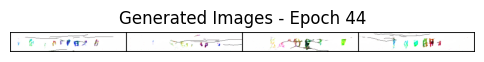

[44/200][0/157]	Loss_D: 1.4703	Loss_G: 1.1554	D(x): 0.7388	D(G(z)): 0.6778 / 0.3229
[44/200][50/157]	Loss_D: 1.2465	Loss_G: 0.6229	D(x): 0.4986	D(G(z)): 0.4031 / 0.5427
[44/200][100/157]	Loss_D: 1.3267	Loss_G: 1.2623	D(x): 0.6839	D(G(z)): 0.5985 / 0.2922
[44/200][150/157]	Loss_D: 1.3272	Loss_G: 1.6333	D(x): 0.7260	D(G(z)): 0.6237 / 0.2054


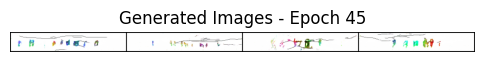

[45/200][0/157]	Loss_D: 1.2545	Loss_G: 0.5541	D(x): 0.4430	D(G(z)): 0.3399 / 0.5805
[45/200][50/157]	Loss_D: 1.2455	Loss_G: 1.0888	D(x): 0.6379	D(G(z)): 0.5361 / 0.3473
[45/200][100/157]	Loss_D: 1.3792	Loss_G: 1.2586	D(x): 0.6766	D(G(z)): 0.6127 / 0.2924
[45/200][150/157]	Loss_D: 1.3991	Loss_G: 0.5116	D(x): 0.3642	D(G(z)): 0.3009 / 0.6032


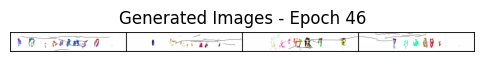

[46/200][0/157]	Loss_D: 1.3866	Loss_G: 1.5216	D(x): 0.7230	D(G(z)): 0.6432 / 0.2252
[46/200][50/157]	Loss_D: 1.2160	Loss_G: 0.8737	D(x): 0.5902	D(G(z)): 0.4833 / 0.4255
[46/200][100/157]	Loss_D: 1.2794	Loss_G: 0.6202	D(x): 0.4533	D(G(z)): 0.3637 / 0.5453
[46/200][150/157]	Loss_D: 1.4712	Loss_G: 0.4316	D(x): 0.3250	D(G(z)): 0.2703 / 0.6558


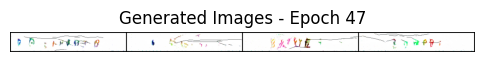

[47/200][0/157]	Loss_D: 1.2757	Loss_G: 1.3264	D(x): 0.6957	D(G(z)): 0.5829 / 0.2756
[47/200][50/157]	Loss_D: 1.3523	Loss_G: 0.5959	D(x): 0.4197	D(G(z)): 0.3613 / 0.5589
[47/200][100/157]	Loss_D: 1.4165	Loss_G: 1.2186	D(x): 0.7167	D(G(z)): 0.6489 / 0.3060
[47/200][150/157]	Loss_D: 1.2188	Loss_G: 0.9612	D(x): 0.5694	D(G(z)): 0.4670 / 0.3906


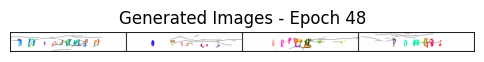

[48/200][0/157]	Loss_D: 1.3495	Loss_G: 2.1226	D(x): 0.7241	D(G(z)): 0.6283 / 0.1284
[48/200][50/157]	Loss_D: 1.3378	Loss_G: 0.5844	D(x): 0.4279	D(G(z)): 0.3673 / 0.5647
[48/200][100/157]	Loss_D: 1.3866	Loss_G: 1.4817	D(x): 0.7169	D(G(z)): 0.6392 / 0.2431
[48/200][150/157]	Loss_D: 1.4666	Loss_G: 0.4181	D(x): 0.3210	D(G(z)): 0.2501 / 0.6644


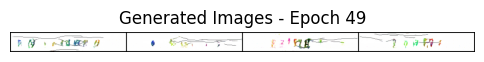

[49/200][0/157]	Loss_D: 1.5613	Loss_G: 1.6170	D(x): 0.7545	D(G(z)): 0.7051 / 0.2076
[49/200][50/157]	Loss_D: 1.3537	Loss_G: 0.4942	D(x): 0.4149	D(G(z)): 0.3553 / 0.6159
[49/200][100/157]	Loss_D: 1.3467	Loss_G: 1.4162	D(x): 0.7138	D(G(z)): 0.6224 / 0.2522
[49/200][150/157]	Loss_D: 1.2849	Loss_G: 0.8394	D(x): 0.5141	D(G(z)): 0.4424 / 0.4447


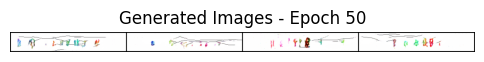

[50/200][0/157]	Loss_D: 1.3819	Loss_G: 0.4758	D(x): 0.3896	D(G(z)): 0.3230 / 0.6260
[50/200][50/157]	Loss_D: 1.2677	Loss_G: 1.0207	D(x): 0.6101	D(G(z)): 0.5268 / 0.3728
[50/200][100/157]	Loss_D: 1.3796	Loss_G: 1.5576	D(x): 0.7024	D(G(z)): 0.6275 / 0.2259
[50/200][150/157]	Loss_D: 1.3125	Loss_G: 0.4726	D(x): 0.4198	D(G(z)): 0.3292 / 0.6273


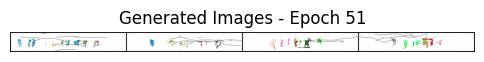

[51/200][0/157]	Loss_D: 1.4288	Loss_G: 1.1907	D(x): 0.6543	D(G(z)): 0.6131 / 0.3172
[51/200][50/157]	Loss_D: 1.3073	Loss_G: 1.0683	D(x): 0.5911	D(G(z)): 0.5243 / 0.3552
[51/200][100/157]	Loss_D: 1.4094	Loss_G: 1.4443	D(x): 0.7654	D(G(z)): 0.6727 / 0.2450
[51/200][150/157]	Loss_D: 1.2760	Loss_G: 0.7800	D(x): 0.4541	D(G(z)): 0.3628 / 0.4717


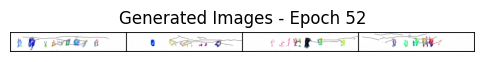

[52/200][0/157]	Loss_D: 1.3067	Loss_G: 0.7179	D(x): 0.4759	D(G(z)): 0.4064 / 0.4961
[52/200][50/157]	Loss_D: 1.8679	Loss_G: 0.3440	D(x): 0.1932	D(G(z)): 0.1608 / 0.7122
[52/200][100/157]	Loss_D: 1.2755	Loss_G: 0.5830	D(x): 0.4906	D(G(z)): 0.4059 / 0.5669
[52/200][150/157]	Loss_D: 1.3328	Loss_G: 1.2279	D(x): 0.6986	D(G(z)): 0.6126 / 0.3088


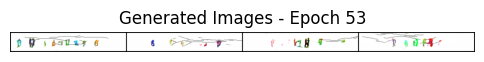

[53/200][0/157]	Loss_D: 1.2620	Loss_G: 0.5733	D(x): 0.4851	D(G(z)): 0.3923 / 0.5768
[53/200][50/157]	Loss_D: 1.5252	Loss_G: 0.4274	D(x): 0.2900	D(G(z)): 0.2051 / 0.6632
[53/200][100/157]	Loss_D: 1.2829	Loss_G: 1.4446	D(x): 0.7520	D(G(z)): 0.6182 / 0.2447
[53/200][150/157]	Loss_D: 1.2862	Loss_G: 0.7787	D(x): 0.5526	D(G(z)): 0.4810 / 0.4681


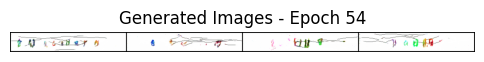

[54/200][0/157]	Loss_D: 1.6095	Loss_G: 1.5423	D(x): 0.8062	D(G(z)): 0.7420 / 0.2267
[54/200][50/157]	Loss_D: 1.2185	Loss_G: 0.6289	D(x): 0.4901	D(G(z)): 0.3735 / 0.5432
[54/200][100/157]	Loss_D: 1.2007	Loss_G: 0.8128	D(x): 0.5643	D(G(z)): 0.4476 / 0.4581
[54/200][150/157]	Loss_D: 1.4865	Loss_G: 0.3986	D(x): 0.3107	D(G(z)): 0.2374 / 0.6781


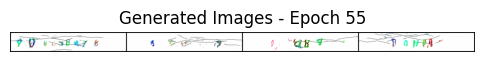

[55/200][0/157]	Loss_D: 1.3147	Loss_G: 1.1194	D(x): 0.6280	D(G(z)): 0.5610 / 0.3400
[55/200][50/157]	Loss_D: 1.3601	Loss_G: 1.5596	D(x): 0.7558	D(G(z)): 0.6481 / 0.2257
[55/200][100/157]	Loss_D: 1.2298	Loss_G: 0.8909	D(x): 0.6312	D(G(z)): 0.5233 / 0.4200
[55/200][150/157]	Loss_D: 1.2965	Loss_G: 1.2670	D(x): 0.7151	D(G(z)): 0.6004 / 0.2921


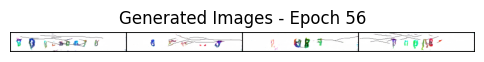

[56/200][0/157]	Loss_D: 1.3855	Loss_G: 0.5827	D(x): 0.3854	D(G(z)): 0.3220 / 0.5712
[56/200][50/157]	Loss_D: 1.6551	Loss_G: 0.3992	D(x): 0.2463	D(G(z)): 0.1715 / 0.6792
[56/200][100/157]	Loss_D: 1.2492	Loss_G: 1.0737	D(x): 0.6295	D(G(z)): 0.5301 / 0.3520
[56/200][150/157]	Loss_D: 1.3175	Loss_G: 0.7618	D(x): 0.4479	D(G(z)): 0.3750 / 0.4751


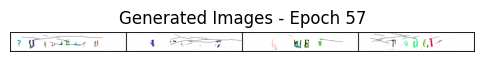

[57/200][0/157]	Loss_D: 1.3777	Loss_G: 1.4240	D(x): 0.7376	D(G(z)): 0.6431 / 0.2556
[57/200][50/157]	Loss_D: 1.4955	Loss_G: 0.4957	D(x): 0.3014	D(G(z)): 0.2224 / 0.6169
[57/200][100/157]	Loss_D: 1.3984	Loss_G: 1.4419	D(x): 0.7421	D(G(z)): 0.6561 / 0.2427
[57/200][150/157]	Loss_D: 1.4814	Loss_G: 0.4641	D(x): 0.3044	D(G(z)): 0.2246 / 0.6372


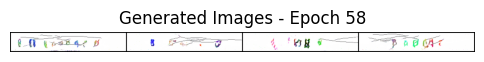

[58/200][0/157]	Loss_D: 1.1699	Loss_G: 1.3188	D(x): 0.6796	D(G(z)): 0.5269 / 0.2820
[58/200][50/157]	Loss_D: 1.3279	Loss_G: 1.2597	D(x): 0.6697	D(G(z)): 0.5817 / 0.2919
[58/200][100/157]	Loss_D: 1.2903	Loss_G: 0.7435	D(x): 0.4291	D(G(z)): 0.3330 / 0.4886
[58/200][150/157]	Loss_D: 1.5516	Loss_G: 0.4179	D(x): 0.2750	D(G(z)): 0.2046 / 0.6642


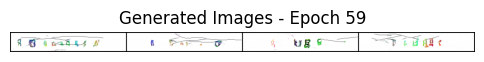

[59/200][0/157]	Loss_D: 1.2408	Loss_G: 0.8577	D(x): 0.6171	D(G(z)): 0.5159 / 0.4315
[59/200][50/157]	Loss_D: 1.3354	Loss_G: 0.9538	D(x): 0.6717	D(G(z)): 0.5932 / 0.3941
[59/200][100/157]	Loss_D: 1.4734	Loss_G: 0.4856	D(x): 0.3187	D(G(z)): 0.2532 / 0.6266
[59/200][150/157]	Loss_D: 1.2587	Loss_G: 1.7197	D(x): 0.6935	D(G(z)): 0.5767 / 0.1888


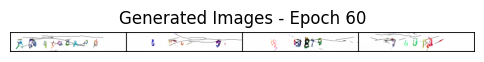

[60/200][0/157]	Loss_D: 1.2582	Loss_G: 0.7442	D(x): 0.4526	D(G(z)): 0.3463 / 0.4977
[60/200][50/157]	Loss_D: 1.3075	Loss_G: 0.7677	D(x): 0.5513	D(G(z)): 0.4850 / 0.4765
[60/200][100/157]	Loss_D: 1.2378	Loss_G: 0.7714	D(x): 0.4968	D(G(z)): 0.3923 / 0.4762
[60/200][150/157]	Loss_D: 1.3733	Loss_G: 0.5571	D(x): 0.3466	D(G(z)): 0.2467 / 0.5868


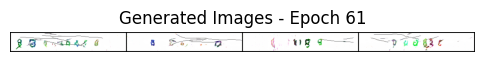

[61/200][0/157]	Loss_D: 1.4279	Loss_G: 1.4028	D(x): 0.6869	D(G(z)): 0.6374 / 0.2590
[61/200][50/157]	Loss_D: 1.2585	Loss_G: 1.1690	D(x): 0.6323	D(G(z)): 0.5300 / 0.3225
[61/200][100/157]	Loss_D: 1.1890	Loss_G: 1.0703	D(x): 0.6161	D(G(z)): 0.4875 / 0.3511
[61/200][150/157]	Loss_D: 1.2633	Loss_G: 0.6133	D(x): 0.4274	D(G(z)): 0.3186 / 0.5543


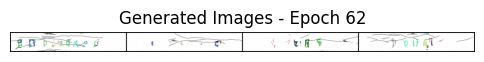

[62/200][0/157]	Loss_D: 1.2820	Loss_G: 0.9167	D(x): 0.5004	D(G(z)): 0.4205 / 0.4184
[62/200][50/157]	Loss_D: 1.3443	Loss_G: 0.5674	D(x): 0.3750	D(G(z)): 0.2653 / 0.5790
[62/200][100/157]	Loss_D: 1.3267	Loss_G: 0.4998	D(x): 0.3773	D(G(z)): 0.2679 / 0.6146
[62/200][150/157]	Loss_D: 1.2202	Loss_G: 0.6631	D(x): 0.4766	D(G(z)): 0.3565 / 0.5265


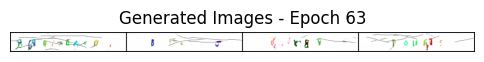

[63/200][0/157]	Loss_D: 1.2708	Loss_G: 0.5147	D(x): 0.4486	D(G(z)): 0.3484 / 0.6078
[63/200][50/157]	Loss_D: 1.2051	Loss_G: 0.9493	D(x): 0.5687	D(G(z)): 0.4560 / 0.4072
[63/200][100/157]	Loss_D: 1.1598	Loss_G: 0.6841	D(x): 0.4619	D(G(z)): 0.2981 / 0.5152
[63/200][150/157]	Loss_D: 1.4323	Loss_G: 1.4880	D(x): 0.7465	D(G(z)): 0.6624 / 0.2461


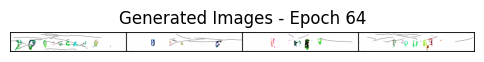

[64/200][0/157]	Loss_D: 1.2273	Loss_G: 1.2976	D(x): 0.6397	D(G(z)): 0.5215 / 0.2900
[64/200][50/157]	Loss_D: 1.2567	Loss_G: 0.6384	D(x): 0.4505	D(G(z)): 0.3450 / 0.5393
[64/200][100/157]	Loss_D: 1.3832	Loss_G: 1.1948	D(x): 0.7207	D(G(z)): 0.6391 / 0.3193
[64/200][150/157]	Loss_D: 1.3042	Loss_G: 1.0646	D(x): 0.6332	D(G(z)): 0.5532 / 0.3594


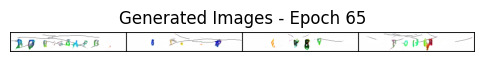

[65/200][0/157]	Loss_D: 1.2364	Loss_G: 0.5764	D(x): 0.4484	D(G(z)): 0.3205 / 0.5719
[65/200][50/157]	Loss_D: 1.3068	Loss_G: 1.5456	D(x): 0.7449	D(G(z)): 0.6161 / 0.2343
[65/200][100/157]	Loss_D: 1.1747	Loss_G: 0.8080	D(x): 0.4957	D(G(z)): 0.3541 / 0.4564
[65/200][150/157]	Loss_D: 1.4840	Loss_G: 1.8093	D(x): 0.7864	D(G(z)): 0.6929 / 0.1756


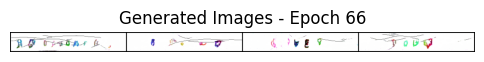

[66/200][0/157]	Loss_D: 1.2949	Loss_G: 0.5438	D(x): 0.3869	D(G(z)): 0.2627 / 0.5912
[66/200][50/157]	Loss_D: 1.1165	Loss_G: 0.7368	D(x): 0.5217	D(G(z)): 0.3524 / 0.4970
[66/200][100/157]	Loss_D: 1.3631	Loss_G: 1.6627	D(x): 0.7796	D(G(z)): 0.6537 / 0.2033
[66/200][150/157]	Loss_D: 1.0822	Loss_G: 1.2123	D(x): 0.6624	D(G(z)): 0.4714 / 0.3132


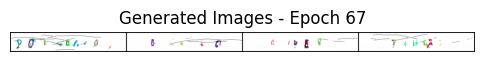

[67/200][0/157]	Loss_D: 1.4282	Loss_G: 0.3156	D(x): 0.3183	D(G(z)): 0.1825 / 0.7349
[67/200][50/157]	Loss_D: 1.0432	Loss_G: 1.0012	D(x): 0.6126	D(G(z)): 0.4099 / 0.3787
[67/200][100/157]	Loss_D: 1.3623	Loss_G: 1.4436	D(x): 0.7480	D(G(z)): 0.6381 / 0.2518
[67/200][150/157]	Loss_D: 1.1448	Loss_G: 0.4428	D(x): 0.4625	D(G(z)): 0.2868 / 0.6497


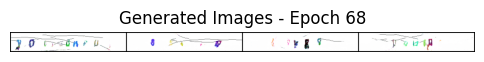

[68/200][0/157]	Loss_D: 1.1691	Loss_G: 1.1414	D(x): 0.6939	D(G(z)): 0.5326 / 0.3447
[68/200][50/157]	Loss_D: 1.1684	Loss_G: 0.6301	D(x): 0.4889	D(G(z)): 0.3459 / 0.5518
[68/200][100/157]	Loss_D: 1.1620	Loss_G: 0.7668	D(x): 0.4465	D(G(z)): 0.2650 / 0.4775
[68/200][150/157]	Loss_D: 1.4483	Loss_G: 1.7261	D(x): 0.8090	D(G(z)): 0.6948 / 0.1899


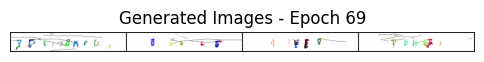

[69/200][0/157]	Loss_D: 1.1531	Loss_G: 1.3847	D(x): 0.6443	D(G(z)): 0.4938 / 0.2754
[69/200][50/157]	Loss_D: 1.3950	Loss_G: 1.3622	D(x): 0.7459	D(G(z)): 0.6532 / 0.2745
[69/200][100/157]	Loss_D: 1.2227	Loss_G: 1.1988	D(x): 0.6923	D(G(z)): 0.5515 / 0.3191
[69/200][150/157]	Loss_D: 1.1571	Loss_G: 0.7034	D(x): 0.5280	D(G(z)): 0.3802 / 0.5064


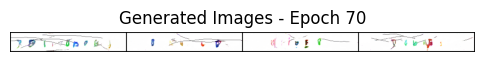

[70/200][0/157]	Loss_D: 1.2542	Loss_G: 1.6105	D(x): 0.7049	D(G(z)): 0.5768 / 0.2150
[70/200][50/157]	Loss_D: 1.2494	Loss_G: 1.1599	D(x): 0.6383	D(G(z)): 0.5349 / 0.3280
[70/200][100/157]	Loss_D: 1.1403	Loss_G: 1.2093	D(x): 0.6383	D(G(z)): 0.4785 / 0.3176
[70/200][150/157]	Loss_D: 1.2314	Loss_G: 1.1709	D(x): 0.6854	D(G(z)): 0.5534 / 0.3273


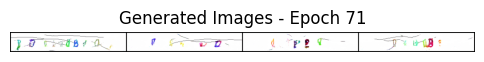

[71/200][0/157]	Loss_D: 1.1988	Loss_G: 0.7799	D(x): 0.4708	D(G(z)): 0.3279 / 0.4706
[71/200][50/157]	Loss_D: 1.1941	Loss_G: 1.2466	D(x): 0.7327	D(G(z)): 0.5630 / 0.3057
[71/200][100/157]	Loss_D: 1.0854	Loss_G: 1.0746	D(x): 0.6435	D(G(z)): 0.4557 / 0.3590
[71/200][150/157]	Loss_D: 1.3083	Loss_G: 0.6104	D(x): 0.3970	D(G(z)): 0.2758 / 0.5541


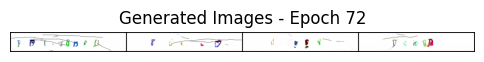

[72/200][0/157]	Loss_D: 1.1025	Loss_G: 0.8527	D(x): 0.5471	D(G(z)): 0.3667 / 0.4369
[72/200][50/157]	Loss_D: 1.1363	Loss_G: 0.7597	D(x): 0.5235	D(G(z)): 0.3541 / 0.4801
[72/200][100/157]	Loss_D: 1.1709	Loss_G: 0.6790	D(x): 0.4776	D(G(z)): 0.3194 / 0.5238
[72/200][150/157]	Loss_D: 1.3179	Loss_G: 1.4886	D(x): 0.7737	D(G(z)): 0.6323 / 0.2478


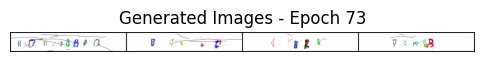

[73/200][0/157]	Loss_D: 1.1179	Loss_G: 0.9413	D(x): 0.5722	D(G(z)): 0.3901 / 0.4055
[73/200][50/157]	Loss_D: 1.3098	Loss_G: 0.4271	D(x): 0.3809	D(G(z)): 0.2456 / 0.6618
[73/200][100/157]	Loss_D: 1.1380	Loss_G: 0.7519	D(x): 0.5206	D(G(z)): 0.3572 / 0.4825
[73/200][150/157]	Loss_D: 1.2429	Loss_G: 0.7032	D(x): 0.4325	D(G(z)): 0.3017 / 0.5088


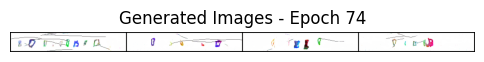

[74/200][0/157]	Loss_D: 1.1612	Loss_G: 1.3548	D(x): 0.7856	D(G(z)): 0.5840 / 0.2780
[74/200][50/157]	Loss_D: 1.0790	Loss_G: 0.5775	D(x): 0.5172	D(G(z)): 0.3071 / 0.5736
[74/200][100/157]	Loss_D: 1.1404	Loss_G: 1.3130	D(x): 0.6286	D(G(z)): 0.4684 / 0.2836
[74/200][150/157]	Loss_D: 1.1868	Loss_G: 1.5792	D(x): 0.7688	D(G(z)): 0.5868 / 0.2238


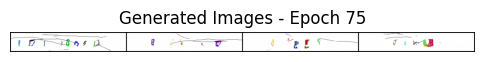

[75/200][0/157]	Loss_D: 1.0699	Loss_G: 0.9384	D(x): 0.5355	D(G(z)): 0.3343 / 0.4117
[75/200][50/157]	Loss_D: 1.1825	Loss_G: 0.3424	D(x): 0.4228	D(G(z)): 0.2355 / 0.7151
[75/200][100/157]	Loss_D: 1.2489	Loss_G: 1.3755	D(x): 0.7350	D(G(z)): 0.5880 / 0.2649
[75/200][150/157]	Loss_D: 1.2926	Loss_G: 1.1670	D(x): 0.7821	D(G(z)): 0.6287 / 0.3350


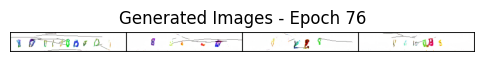

[76/200][0/157]	Loss_D: 1.1409	Loss_G: 0.8753	D(x): 0.5892	D(G(z)): 0.4369 / 0.4297
[76/200][50/157]	Loss_D: 1.0697	Loss_G: 1.2653	D(x): 0.6674	D(G(z)): 0.4650 / 0.3057
[76/200][100/157]	Loss_D: 1.5576	Loss_G: 2.5965	D(x): 0.8654	D(G(z)): 0.7391 / 0.0904
[76/200][150/157]	Loss_D: 1.0725	Loss_G: 0.9449	D(x): 0.5979	D(G(z)): 0.3932 / 0.4086


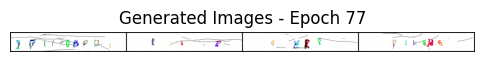

[77/200][0/157]	Loss_D: 1.4097	Loss_G: 2.4426	D(x): 0.7768	D(G(z)): 0.6601 / 0.0996
[77/200][50/157]	Loss_D: 1.0872	Loss_G: 0.7767	D(x): 0.5454	D(G(z)): 0.3448 / 0.4734
[77/200][100/157]	Loss_D: 1.1248	Loss_G: 1.1894	D(x): 0.6491	D(G(z)): 0.4781 / 0.3280
[77/200][150/157]	Loss_D: 1.0240	Loss_G: 1.3885	D(x): 0.6726	D(G(z)): 0.4417 / 0.2640


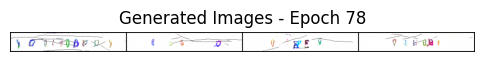

[78/200][0/157]	Loss_D: 1.1109	Loss_G: 0.7963	D(x): 0.4858	D(G(z)): 0.2893 / 0.4749
[78/200][50/157]	Loss_D: 1.3792	Loss_G: 1.5648	D(x): 0.7833	D(G(z)): 0.6573 / 0.2309
[78/200][100/157]	Loss_D: 1.3439	Loss_G: 1.9687	D(x): 0.8034	D(G(z)): 0.6573 / 0.1506
[78/200][150/157]	Loss_D: 1.1228	Loss_G: 0.7616	D(x): 0.4984	D(G(z)): 0.3193 / 0.4778


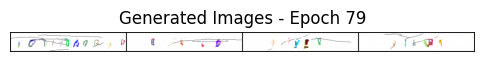

[79/200][0/157]	Loss_D: 1.5273	Loss_G: 0.4567	D(x): 0.2740	D(G(z)): 0.1367 / 0.6417
[79/200][50/157]	Loss_D: 1.1297	Loss_G: 1.5098	D(x): 0.7343	D(G(z)): 0.5421 / 0.2442
[79/200][100/157]	Loss_D: 1.3384	Loss_G: 0.5521	D(x): 0.3646	D(G(z)): 0.2217 / 0.5913
[79/200][150/157]	Loss_D: 1.2829	Loss_G: 1.2330	D(x): 0.6423	D(G(z)): 0.5440 / 0.3146


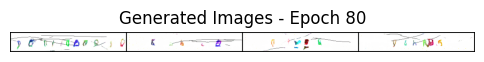

[80/200][0/157]	Loss_D: 1.1298	Loss_G: 0.6127	D(x): 0.4603	D(G(z)): 0.2595 / 0.5557
[80/200][50/157]	Loss_D: 1.0291	Loss_G: 0.6563	D(x): 0.5217	D(G(z)): 0.2827 / 0.5333
[80/200][100/157]	Loss_D: 1.1685	Loss_G: 0.6753	D(x): 0.4345	D(G(z)): 0.2542 / 0.5258
[80/200][150/157]	Loss_D: 1.0131	Loss_G: 0.8720	D(x): 0.6388	D(G(z)): 0.4037 / 0.4428


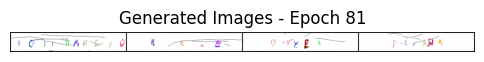

[81/200][0/157]	Loss_D: 1.0596	Loss_G: 0.7895	D(x): 0.6510	D(G(z)): 0.4365 / 0.4723
[81/200][50/157]	Loss_D: 1.0891	Loss_G: 0.7110	D(x): 0.4828	D(G(z)): 0.2672 / 0.5133
[81/200][100/157]	Loss_D: 1.0734	Loss_G: 0.8081	D(x): 0.6006	D(G(z)): 0.3944 / 0.4653
[81/200][150/157]	Loss_D: 1.1308	Loss_G: 1.7688	D(x): 0.7549	D(G(z)): 0.5492 / 0.1815


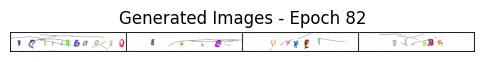

[82/200][0/157]	Loss_D: 0.9701	Loss_G: 1.2432	D(x): 0.6155	D(G(z)): 0.3517 / 0.3267
[82/200][50/157]	Loss_D: 1.0970	Loss_G: 0.6802	D(x): 0.4701	D(G(z)): 0.2587 / 0.5265
[82/200][100/157]	Loss_D: 1.0262	Loss_G: 1.0840	D(x): 0.6192	D(G(z)): 0.3988 / 0.3565
[82/200][150/157]	Loss_D: 1.0410	Loss_G: 1.4974	D(x): 0.7202	D(G(z)): 0.4782 / 0.2408


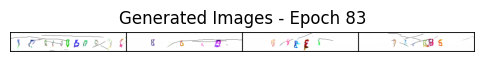

[83/200][0/157]	Loss_D: 0.9076	Loss_G: 0.9628	D(x): 0.5943	D(G(z)): 0.3023 / 0.3995
[83/200][50/157]	Loss_D: 1.1733	Loss_G: 0.9004	D(x): 0.4925	D(G(z)): 0.3377 / 0.4223
[83/200][100/157]	Loss_D: 0.9885	Loss_G: 1.0992	D(x): 0.6344	D(G(z)): 0.3926 / 0.3450
[83/200][150/157]	Loss_D: 1.0383	Loss_G: 0.7142	D(x): 0.5233	D(G(z)): 0.2901 / 0.5097


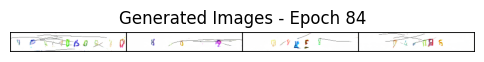

[84/200][0/157]	Loss_D: 1.1325	Loss_G: 1.3024	D(x): 0.6475	D(G(z)): 0.4700 / 0.2941
[84/200][50/157]	Loss_D: 1.1407	Loss_G: 0.6437	D(x): 0.4429	D(G(z)): 0.2328 / 0.5478
[84/200][100/157]	Loss_D: 1.2151	Loss_G: 2.2224	D(x): 0.8279	D(G(z)): 0.6148 / 0.1230
[84/200][150/157]	Loss_D: 1.0807	Loss_G: 0.8605	D(x): 0.4617	D(G(z)): 0.2164 / 0.4381


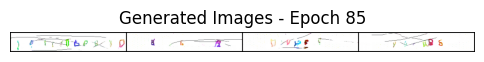

[85/200][0/157]	Loss_D: 1.2105	Loss_G: 0.8313	D(x): 0.5076	D(G(z)): 0.3861 / 0.4663
[85/200][50/157]	Loss_D: 1.0760	Loss_G: 1.6878	D(x): 0.8008	D(G(z)): 0.5477 / 0.2148
[85/200][100/157]	Loss_D: 1.1104	Loss_G: 0.7212	D(x): 0.4832	D(G(z)): 0.2750 / 0.5072
[85/200][150/157]	Loss_D: 1.0915	Loss_G: 0.7012	D(x): 0.5083	D(G(z)): 0.3075 / 0.5106


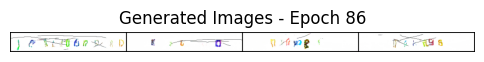

[86/200][0/157]	Loss_D: 1.4388	Loss_G: 1.4988	D(x): 0.8343	D(G(z)): 0.6900 / 0.2456
[86/200][50/157]	Loss_D: 1.4176	Loss_G: 1.6634	D(x): 0.7313	D(G(z)): 0.6380 / 0.2174
[86/200][100/157]	Loss_D: 1.0393	Loss_G: 1.0605	D(x): 0.6193	D(G(z)): 0.3958 / 0.3757
[86/200][150/157]	Loss_D: 1.0171	Loss_G: 1.0456	D(x): 0.5971	D(G(z)): 0.3536 / 0.3787


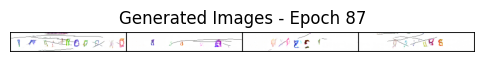

[87/200][0/157]	Loss_D: 1.0424	Loss_G: 0.7808	D(x): 0.5308	D(G(z)): 0.2650 / 0.4879
[87/200][50/157]	Loss_D: 1.1315	Loss_G: 1.4598	D(x): 0.6346	D(G(z)): 0.4586 / 0.2697
[87/200][100/157]	Loss_D: 0.9709	Loss_G: 1.2309	D(x): 0.6223	D(G(z)): 0.3676 / 0.3173
[87/200][150/157]	Loss_D: 1.0541	Loss_G: 1.5078	D(x): 0.7118	D(G(z)): 0.4760 / 0.2466


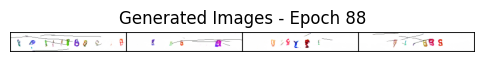

[88/200][0/157]	Loss_D: 1.2910	Loss_G: 0.6122	D(x): 0.3412	D(G(z)): 0.1420 / 0.5743
[88/200][50/157]	Loss_D: 1.0652	Loss_G: 1.0297	D(x): 0.5695	D(G(z)): 0.3582 / 0.3805
[88/200][100/157]	Loss_D: 1.1044	Loss_G: 0.8215	D(x): 0.5744	D(G(z)): 0.3950 / 0.4678
[88/200][150/157]	Loss_D: 1.1218	Loss_G: 1.1272	D(x): 0.6194	D(G(z)): 0.4396 / 0.3467


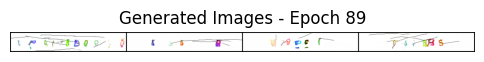

[89/200][0/157]	Loss_D: 1.1326	Loss_G: 0.8267	D(x): 0.4632	D(G(z)): 0.2360 / 0.4569
[89/200][50/157]	Loss_D: 1.0566	Loss_G: 1.1862	D(x): 0.6710	D(G(z)): 0.4585 / 0.3343
[89/200][100/157]	Loss_D: 1.0406	Loss_G: 1.6040	D(x): 0.6959	D(G(z)): 0.4549 / 0.2227
[89/200][150/157]	Loss_D: 1.0319	Loss_G: 0.5490	D(x): 0.4528	D(G(z)): 0.1546 / 0.5932


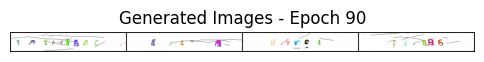

[90/200][0/157]	Loss_D: 1.3704	Loss_G: 0.5493	D(x): 0.3337	D(G(z)): 0.1537 / 0.5990
[90/200][50/157]	Loss_D: 1.3180	Loss_G: 0.6794	D(x): 0.3705	D(G(z)): 0.2050 / 0.5301
[90/200][100/157]	Loss_D: 0.9646	Loss_G: 0.8563	D(x): 0.6044	D(G(z)): 0.3308 / 0.4397
[90/200][150/157]	Loss_D: 1.1652	Loss_G: 1.4703	D(x): 0.7553	D(G(z)): 0.5607 / 0.2533


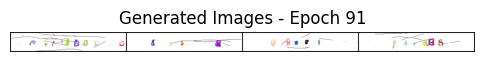

[91/200][0/157]	Loss_D: 1.0947	Loss_G: 1.6229	D(x): 0.7375	D(G(z)): 0.5104 / 0.2186
[91/200][50/157]	Loss_D: 1.0792	Loss_G: 1.1083	D(x): 0.6446	D(G(z)): 0.4488 / 0.3561
[91/200][100/157]	Loss_D: 1.2102	Loss_G: 1.4212	D(x): 0.7947	D(G(z)): 0.5951 / 0.2614
[91/200][150/157]	Loss_D: 1.3620	Loss_G: 0.4551	D(x): 0.3399	D(G(z)): 0.1887 / 0.6476


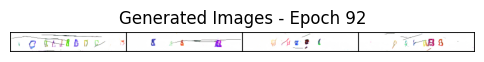

[92/200][0/157]	Loss_D: 1.0560	Loss_G: 1.3702	D(x): 0.6905	D(G(z)): 0.4618 / 0.2775
[92/200][50/157]	Loss_D: 0.9682	Loss_G: 0.9420	D(x): 0.6067	D(G(z)): 0.3457 / 0.4129
[92/200][100/157]	Loss_D: 1.0718	Loss_G: 1.0534	D(x): 0.5346	D(G(z)): 0.3153 / 0.3753
[92/200][150/157]	Loss_D: 1.1389	Loss_G: 1.1059	D(x): 0.7040	D(G(z)): 0.5152 / 0.3545


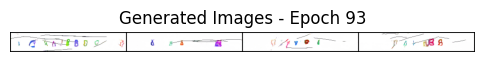

[93/200][0/157]	Loss_D: 0.8952	Loss_G: 1.1023	D(x): 0.6883	D(G(z)): 0.3690 / 0.3649
[93/200][50/157]	Loss_D: 1.0424	Loss_G: 1.8494	D(x): 0.7845	D(G(z)): 0.5135 / 0.1781
[93/200][100/157]	Loss_D: 1.2499	Loss_G: 0.4858	D(x): 0.3731	D(G(z)): 0.1764 / 0.6258
[93/200][150/157]	Loss_D: 1.1997	Loss_G: 2.0605	D(x): 0.7692	D(G(z)): 0.5844 / 0.1590


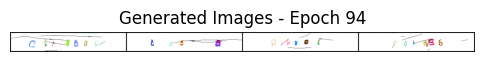

[94/200][0/157]	Loss_D: 0.8667	Loss_G: 1.3799	D(x): 0.7041	D(G(z)): 0.3772 / 0.2783
[94/200][50/157]	Loss_D: 0.9941	Loss_G: 0.7008	D(x): 0.5426	D(G(z)): 0.2807 / 0.5158
[94/200][100/157]	Loss_D: 1.1057	Loss_G: 1.2953	D(x): 0.6853	D(G(z)): 0.4885 / 0.2988
[94/200][150/157]	Loss_D: 1.2836	Loss_G: 0.6957	D(x): 0.3714	D(G(z)): 0.1859 / 0.5255


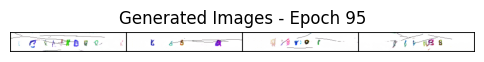

[95/200][0/157]	Loss_D: 0.9411	Loss_G: 0.7583	D(x): 0.6420	D(G(z)): 0.3545 / 0.4913
[95/200][50/157]	Loss_D: 1.0293	Loss_G: 1.4181	D(x): 0.8270	D(G(z)): 0.5445 / 0.2575
[95/200][100/157]	Loss_D: 1.1162	Loss_G: 0.6204	D(x): 0.4422	D(G(z)): 0.2129 / 0.5517
[95/200][150/157]	Loss_D: 1.0343	Loss_G: 1.8582	D(x): 0.7557	D(G(z)): 0.5053 / 0.1701


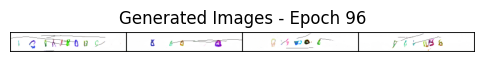

[96/200][0/157]	Loss_D: 1.0157	Loss_G: 1.7015	D(x): 0.7532	D(G(z)): 0.4811 / 0.2216
[96/200][50/157]	Loss_D: 1.1693	Loss_G: 1.9334	D(x): 0.7761	D(G(z)): 0.5726 / 0.1772
[96/200][100/157]	Loss_D: 1.0153	Loss_G: 1.2021	D(x): 0.7449	D(G(z)): 0.4884 / 0.3424
[96/200][150/157]	Loss_D: 0.9686	Loss_G: 0.9728	D(x): 0.6115	D(G(z)): 0.3510 / 0.4029


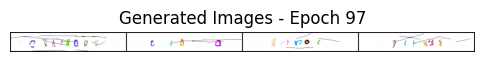

[97/200][0/157]	Loss_D: 1.2901	Loss_G: 1.8485	D(x): 0.8067	D(G(z)): 0.6189 / 0.1838
[97/200][50/157]	Loss_D: 1.1526	Loss_G: 0.6504	D(x): 0.4057	D(G(z)): 0.1442 / 0.5537
[97/200][100/157]	Loss_D: 1.0746	Loss_G: 0.8674	D(x): 0.5231	D(G(z)): 0.2970 / 0.4466
[97/200][150/157]	Loss_D: 1.4969	Loss_G: 3.2192	D(x): 0.8521	D(G(z)): 0.7032 / 0.0494


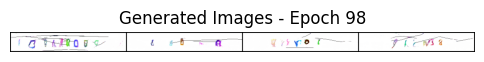

[98/200][0/157]	Loss_D: 1.1275	Loss_G: 2.5643	D(x): 0.7853	D(G(z)): 0.5560 / 0.0951
[98/200][50/157]	Loss_D: 0.8614	Loss_G: 1.0885	D(x): 0.6404	D(G(z)): 0.3110 / 0.3605
[98/200][100/157]	Loss_D: 0.8652	Loss_G: 1.1953	D(x): 0.6573	D(G(z)): 0.3354 / 0.3355
[98/200][150/157]	Loss_D: 0.9920	Loss_G: 0.8876	D(x): 0.5804	D(G(z)): 0.3258 / 0.4476


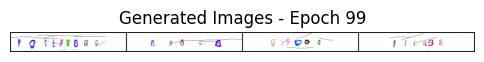

[99/200][0/157]	Loss_D: 1.0329	Loss_G: 1.4211	D(x): 0.8149	D(G(z)): 0.5343 / 0.2747
[99/200][50/157]	Loss_D: 1.0633	Loss_G: 0.7258	D(x): 0.4717	D(G(z)): 0.2171 / 0.5109
[99/200][100/157]	Loss_D: 1.3282	Loss_G: 0.5630	D(x): 0.3368	D(G(z)): 0.1041 / 0.5962
[99/200][150/157]	Loss_D: 0.9751	Loss_G: 1.0011	D(x): 0.5676	D(G(z)): 0.3051 / 0.3899


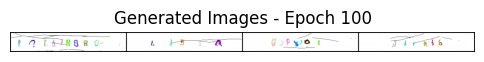

[100/200][0/157]	Loss_D: 1.3321	Loss_G: 2.8570	D(x): 0.8967	D(G(z)): 0.6764 / 0.0710
[100/200][50/157]	Loss_D: 1.0423	Loss_G: 2.4301	D(x): 0.7837	D(G(z)): 0.5269 / 0.1028
[100/200][100/157]	Loss_D: 0.8870	Loss_G: 1.4245	D(x): 0.7269	D(G(z)): 0.4027 / 0.2676
[100/200][150/157]	Loss_D: 1.1071	Loss_G: 0.5674	D(x): 0.4353	D(G(z)): 0.1741 / 0.5938


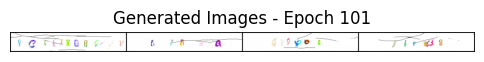

[101/200][0/157]	Loss_D: 1.3135	Loss_G: 2.1587	D(x): 0.8627	D(G(z)): 0.6591 / 0.1358
[101/200][50/157]	Loss_D: 0.8991	Loss_G: 1.2156	D(x): 0.7088	D(G(z)): 0.3943 / 0.3265
[101/200][100/157]	Loss_D: 1.1322	Loss_G: 0.8227	D(x): 0.4827	D(G(z)): 0.2862 / 0.4660
[101/200][150/157]	Loss_D: 0.9321	Loss_G: 0.6817	D(x): 0.5945	D(G(z)): 0.2989 / 0.5314


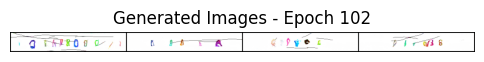

[102/200][0/157]	Loss_D: 1.0552	Loss_G: 1.7315	D(x): 0.8397	D(G(z)): 0.5627 / 0.2084
[102/200][50/157]	Loss_D: 0.9228	Loss_G: 1.3240	D(x): 0.7042	D(G(z)): 0.4069 / 0.2878
[102/200][100/157]	Loss_D: 0.9545	Loss_G: 1.3885	D(x): 0.6869	D(G(z)): 0.3917 / 0.2834
[102/200][150/157]	Loss_D: 1.0031	Loss_G: 0.6444	D(x): 0.5146	D(G(z)): 0.2321 / 0.5474


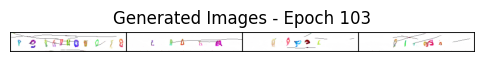

[103/200][0/157]	Loss_D: 1.3595	Loss_G: 1.7176	D(x): 0.7883	D(G(z)): 0.6426 / 0.2064
[103/200][50/157]	Loss_D: 0.9019	Loss_G: 1.4716	D(x): 0.6751	D(G(z)): 0.3687 / 0.2639
[103/200][100/157]	Loss_D: 0.9377	Loss_G: 1.5731	D(x): 0.6942	D(G(z)): 0.4088 / 0.2479
[103/200][150/157]	Loss_D: 1.4470	Loss_G: 0.4086	D(x): 0.3180	D(G(z)): 0.1297 / 0.6789


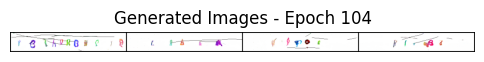

[104/200][0/157]	Loss_D: 0.9352	Loss_G: 0.9827	D(x): 0.6546	D(G(z)): 0.3590 / 0.4076
[104/200][50/157]	Loss_D: 0.9575	Loss_G: 0.9561	D(x): 0.5143	D(G(z)): 0.2085 / 0.4332
[104/200][100/157]	Loss_D: 0.9240	Loss_G: 1.0948	D(x): 0.5743	D(G(z)): 0.2489 / 0.3705
[104/200][150/157]	Loss_D: 1.0827	Loss_G: 1.5654	D(x): 0.7838	D(G(z)): 0.5352 / 0.2466


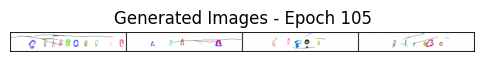

[105/200][0/157]	Loss_D: 1.4780	Loss_G: 2.3533	D(x): 0.9090	D(G(z)): 0.7203 / 0.1148
[105/200][50/157]	Loss_D: 1.2741	Loss_G: 2.3480	D(x): 0.8745	D(G(z)): 0.6567 / 0.1221
[105/200][100/157]	Loss_D: 1.0776	Loss_G: 1.0114	D(x): 0.4632	D(G(z)): 0.1885 / 0.4054
[105/200][150/157]	Loss_D: 1.3646	Loss_G: 0.5892	D(x): 0.3318	D(G(z)): 0.1335 / 0.5843


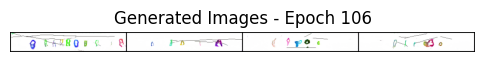

[106/200][0/157]	Loss_D: 0.9070	Loss_G: 0.9677	D(x): 0.5727	D(G(z)): 0.2540 / 0.4193
[106/200][50/157]	Loss_D: 1.5137	Loss_G: 2.0014	D(x): 0.8426	D(G(z)): 0.7140 / 0.1698
[106/200][100/157]	Loss_D: 0.8332	Loss_G: 1.4908	D(x): 0.7092	D(G(z)): 0.3610 / 0.2585
[106/200][150/157]	Loss_D: 1.1341	Loss_G: 0.6272	D(x): 0.4194	D(G(z)): 0.1658 / 0.5599


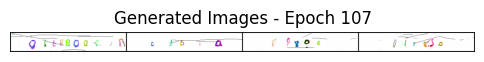

[107/200][0/157]	Loss_D: 0.9107	Loss_G: 0.7012	D(x): 0.5748	D(G(z)): 0.2605 / 0.5383
[107/200][50/157]	Loss_D: 1.3068	Loss_G: 2.0213	D(x): 0.8867	D(G(z)): 0.6538 / 0.1488
[107/200][100/157]	Loss_D: 0.8338	Loss_G: 0.8732	D(x): 0.6697	D(G(z)): 0.3097 / 0.4437
[107/200][150/157]	Loss_D: 0.9434	Loss_G: 1.5469	D(x): 0.6918	D(G(z)): 0.4061 / 0.2417


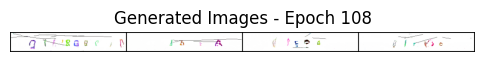

[108/200][0/157]	Loss_D: 1.0236	Loss_G: 0.8779	D(x): 0.5077	D(G(z)): 0.2309 / 0.4641
[108/200][50/157]	Loss_D: 1.0247	Loss_G: 0.7828	D(x): 0.5176	D(G(z)): 0.2468 / 0.4930
[108/200][100/157]	Loss_D: 1.2012	Loss_G: 0.5238	D(x): 0.3988	D(G(z)): 0.1578 / 0.6139
[108/200][150/157]	Loss_D: 1.0641	Loss_G: 1.8475	D(x): 0.8494	D(G(z)): 0.5584 / 0.1829


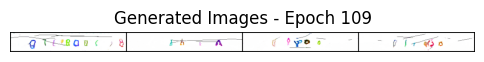

[109/200][0/157]	Loss_D: 0.8464	Loss_G: 1.4518	D(x): 0.7562	D(G(z)): 0.3988 / 0.2564
[109/200][50/157]	Loss_D: 1.4206	Loss_G: 0.5688	D(x): 0.2990	D(G(z)): 0.1080 / 0.5931
[109/200][100/157]	Loss_D: 0.9867	Loss_G: 1.8988	D(x): 0.8413	D(G(z)): 0.5123 / 0.1704
[109/200][150/157]	Loss_D: 1.1642	Loss_G: 1.9907	D(x): 0.8003	D(G(z)): 0.5775 / 0.1577


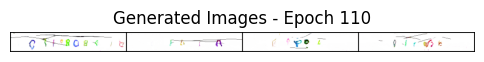

[110/200][0/157]	Loss_D: 1.0940	Loss_G: 0.4312	D(x): 0.4536	D(G(z)): 0.2037 / 0.6733
[110/200][50/157]	Loss_D: 0.7870	Loss_G: 0.6738	D(x): 0.5937	D(G(z)): 0.1932 / 0.5456
[110/200][100/157]	Loss_D: 0.8779	Loss_G: 1.2367	D(x): 0.6303	D(G(z)): 0.3040 / 0.3258
[110/200][150/157]	Loss_D: 0.8742	Loss_G: 1.1876	D(x): 0.6449	D(G(z)): 0.3164 / 0.3357


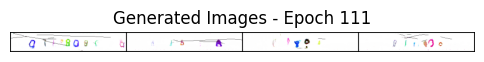

[111/200][0/157]	Loss_D: 1.1803	Loss_G: 0.6025	D(x): 0.3854	D(G(z)): 0.1114 / 0.5737
[111/200][50/157]	Loss_D: 0.9058	Loss_G: 0.8412	D(x): 0.5624	D(G(z)): 0.2311 / 0.4656
[111/200][100/157]	Loss_D: 0.9072	Loss_G: 1.5679	D(x): 0.7081	D(G(z)): 0.3972 / 0.2392
[111/200][150/157]	Loss_D: 0.8702	Loss_G: 1.0988	D(x): 0.6095	D(G(z)): 0.2774 / 0.3676


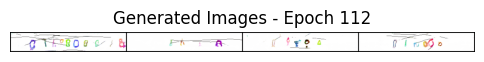

[112/200][0/157]	Loss_D: 0.8156	Loss_G: 1.2620	D(x): 0.6539	D(G(z)): 0.2814 / 0.3274
[112/200][50/157]	Loss_D: 0.9023	Loss_G: 0.7503	D(x): 0.5742	D(G(z)): 0.2475 / 0.5166
[112/200][100/157]	Loss_D: 1.1190	Loss_G: 1.4898	D(x): 0.7446	D(G(z)): 0.5102 / 0.2624
[112/200][150/157]	Loss_D: 0.9439	Loss_G: 1.6710	D(x): 0.7952	D(G(z)): 0.4846 / 0.2129


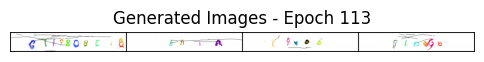

[113/200][0/157]	Loss_D: 1.2610	Loss_G: 2.0269	D(x): 0.8059	D(G(z)): 0.6203 / 0.1495
[113/200][50/157]	Loss_D: 0.7529	Loss_G: 1.5055	D(x): 0.7795	D(G(z)): 0.3665 / 0.2560
[113/200][100/157]	Loss_D: 1.0538	Loss_G: 0.6232	D(x): 0.4550	D(G(z)): 0.1680 / 0.5636
[113/200][150/157]	Loss_D: 0.8833	Loss_G: 1.1552	D(x): 0.7218	D(G(z)): 0.3856 / 0.3377


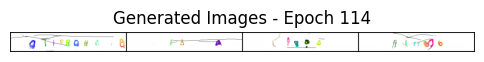

[114/200][0/157]	Loss_D: 1.8485	Loss_G: 0.3706	D(x): 0.2062	D(G(z)): 0.0823 / 0.7060
[114/200][50/157]	Loss_D: 1.2322	Loss_G: 0.3377	D(x): 0.3608	D(G(z)): 0.1142 / 0.7326
[114/200][100/157]	Loss_D: 1.5173	Loss_G: 0.4912	D(x): 0.2733	D(G(z)): 0.0782 / 0.6402
[114/200][150/157]	Loss_D: 0.9737	Loss_G: 0.8492	D(x): 0.5121	D(G(z)): 0.1978 / 0.4613


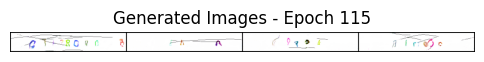

[115/200][0/157]	Loss_D: 1.1436	Loss_G: 1.9847	D(x): 0.8248	D(G(z)): 0.5707 / 0.1706
[115/200][50/157]	Loss_D: 0.7852	Loss_G: 1.5573	D(x): 0.7165	D(G(z)): 0.3341 / 0.2551
[115/200][100/157]	Loss_D: 0.7003	Loss_G: 1.0991	D(x): 0.6707	D(G(z)): 0.2359 / 0.3701
[115/200][150/157]	Loss_D: 0.8447	Loss_G: 1.4623	D(x): 0.7422	D(G(z)): 0.3787 / 0.2653


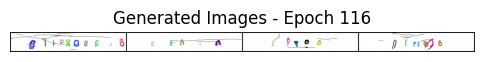

[116/200][0/157]	Loss_D: 1.0355	Loss_G: 1.7333	D(x): 0.7118	D(G(z)): 0.4508 / 0.2145
[116/200][50/157]	Loss_D: 0.7995	Loss_G: 1.2684	D(x): 0.7638	D(G(z)): 0.3760 / 0.3129
[116/200][100/157]	Loss_D: 1.0975	Loss_G: 0.7469	D(x): 0.4352	D(G(z)): 0.1341 / 0.5285
[116/200][150/157]	Loss_D: 0.9779	Loss_G: 1.6448	D(x): 0.7292	D(G(z)): 0.4576 / 0.2328


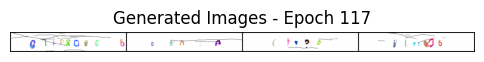

[117/200][0/157]	Loss_D: 1.2232	Loss_G: 3.0987	D(x): 0.8551	D(G(z)): 0.6190 / 0.0563
[117/200][50/157]	Loss_D: 1.1720	Loss_G: 2.0840	D(x): 0.8914	D(G(z)): 0.6119 / 0.1721
[117/200][100/157]	Loss_D: 0.8359	Loss_G: 1.2961	D(x): 0.6558	D(G(z)): 0.3033 / 0.3177
[117/200][150/157]	Loss_D: 0.8434	Loss_G: 1.5662	D(x): 0.6924	D(G(z)): 0.3428 / 0.2508


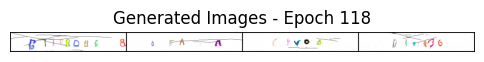

[118/200][0/157]	Loss_D: 0.9230	Loss_G: 0.8067	D(x): 0.5127	D(G(z)): 0.1542 / 0.4816
[118/200][50/157]	Loss_D: 0.9069	Loss_G: 0.7709	D(x): 0.6214	D(G(z)): 0.3101 / 0.4887
[118/200][100/157]	Loss_D: 1.0822	Loss_G: 1.8136	D(x): 0.7855	D(G(z)): 0.5270 / 0.1970
[118/200][150/157]	Loss_D: 1.2713	Loss_G: 0.9307	D(x): 0.3652	D(G(z)): 0.1365 / 0.4351


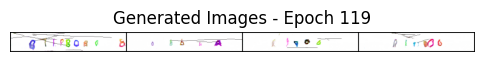

[119/200][0/157]	Loss_D: 1.0396	Loss_G: 0.6191	D(x): 0.4458	D(G(z)): 0.1272 / 0.5706
[119/200][50/157]	Loss_D: 1.0985	Loss_G: 0.5649	D(x): 0.4202	D(G(z)): 0.1409 / 0.6056
[119/200][100/157]	Loss_D: 0.9138	Loss_G: 1.7150	D(x): 0.8528	D(G(z)): 0.5103 / 0.2058
[119/200][150/157]	Loss_D: 1.3558	Loss_G: 0.5998	D(x): 0.3419	D(G(z)): 0.0970 / 0.5740


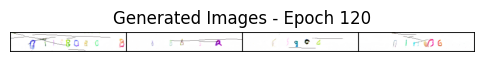

[120/200][0/157]	Loss_D: 0.7504	Loss_G: 1.2926	D(x): 0.6777	D(G(z)): 0.2638 / 0.3184
[120/200][50/157]	Loss_D: 1.1266	Loss_G: 0.7158	D(x): 0.4340	D(G(z)): 0.1310 / 0.5128
[120/200][100/157]	Loss_D: 0.7094	Loss_G: 1.5410	D(x): 0.7287	D(G(z)): 0.2890 / 0.2492
[120/200][150/157]	Loss_D: 0.9568	Loss_G: 2.7094	D(x): 0.8409	D(G(z)): 0.5173 / 0.0889


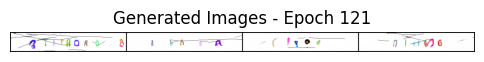

[121/200][0/157]	Loss_D: 1.4116	Loss_G: 2.3377	D(x): 0.8583	D(G(z)): 0.6621 / 0.1349
[121/200][50/157]	Loss_D: 0.9708	Loss_G: 1.3742	D(x): 0.7330	D(G(z)): 0.4508 / 0.3028
[121/200][100/157]	Loss_D: 1.3854	Loss_G: 0.6541	D(x): 0.3102	D(G(z)): 0.0907 / 0.5626
[121/200][150/157]	Loss_D: 1.0029	Loss_G: 2.3081	D(x): 0.8586	D(G(z)): 0.5241 / 0.1218


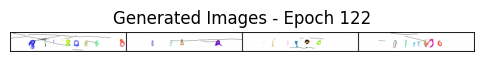

[122/200][0/157]	Loss_D: 0.8469	Loss_G: 1.5700	D(x): 0.7934	D(G(z)): 0.4281 / 0.2392
[122/200][50/157]	Loss_D: 0.7604	Loss_G: 1.4664	D(x): 0.6784	D(G(z)): 0.2769 / 0.2674
[122/200][100/157]	Loss_D: 1.1244	Loss_G: 0.4912	D(x): 0.4378	D(G(z)): 0.1804 / 0.6332
[122/200][150/157]	Loss_D: 1.1845	Loss_G: 0.5494	D(x): 0.3913	D(G(z)): 0.1261 / 0.6204


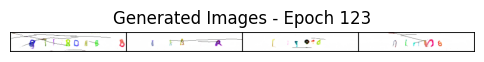

[123/200][0/157]	Loss_D: 0.8496	Loss_G: 1.4973	D(x): 0.7109	D(G(z)): 0.3591 / 0.2674
[123/200][50/157]	Loss_D: 0.9010	Loss_G: 1.5017	D(x): 0.6591	D(G(z)): 0.3513 / 0.2703
[123/200][100/157]	Loss_D: 0.7855	Loss_G: 2.0123	D(x): 0.8598	D(G(z)): 0.4404 / 0.1588
[123/200][150/157]	Loss_D: 1.0952	Loss_G: 0.7822	D(x): 0.4272	D(G(z)): 0.1458 / 0.4931


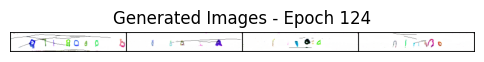

[124/200][0/157]	Loss_D: 1.1184	Loss_G: 0.7699	D(x): 0.4215	D(G(z)): 0.1206 / 0.5192
[124/200][50/157]	Loss_D: 0.8318	Loss_G: 1.4751	D(x): 0.6895	D(G(z)): 0.3329 / 0.2564
[124/200][100/157]	Loss_D: 0.9541	Loss_G: 1.1994	D(x): 0.5463	D(G(z)): 0.2283 / 0.3476
[124/200][150/157]	Loss_D: 0.8170	Loss_G: 1.3880	D(x): 0.7847	D(G(z)): 0.4097 / 0.2876


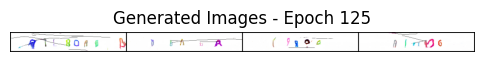

[125/200][0/157]	Loss_D: 0.8522	Loss_G: 1.4052	D(x): 0.7598	D(G(z)): 0.4043 / 0.2741
[125/200][50/157]	Loss_D: 0.8715	Loss_G: 1.1395	D(x): 0.6291	D(G(z)): 0.2844 / 0.3718
[125/200][100/157]	Loss_D: 1.1522	Loss_G: 1.7887	D(x): 0.8646	D(G(z)): 0.6047 / 0.1919
[125/200][150/157]	Loss_D: 0.7565	Loss_G: 0.8615	D(x): 0.6332	D(G(z)): 0.2105 / 0.4694


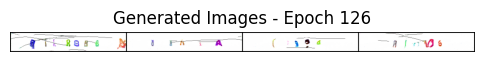

[126/200][0/157]	Loss_D: 0.8965	Loss_G: 0.9157	D(x): 0.6397	D(G(z)): 0.3049 / 0.4438
[126/200][50/157]	Loss_D: 0.9729	Loss_G: 1.2218	D(x): 0.7732	D(G(z)): 0.4652 / 0.3355
[126/200][100/157]	Loss_D: 1.1672	Loss_G: 2.6411	D(x): 0.8381	D(G(z)): 0.5837 / 0.0834
[126/200][150/157]	Loss_D: 0.8224	Loss_G: 1.5678	D(x): 0.6737	D(G(z)): 0.2864 / 0.2461


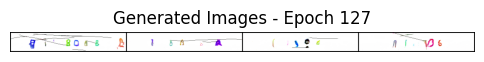

[127/200][0/157]	Loss_D: 0.7420	Loss_G: 1.4426	D(x): 0.7044	D(G(z)): 0.2867 / 0.2903
[127/200][50/157]	Loss_D: 0.8995	Loss_G: 2.1377	D(x): 0.7997	D(G(z)): 0.4480 / 0.1413
[127/200][100/157]	Loss_D: 0.8752	Loss_G: 1.2233	D(x): 0.6578	D(G(z)): 0.3206 / 0.3311
[127/200][150/157]	Loss_D: 0.8080	Loss_G: 0.9877	D(x): 0.6095	D(G(z)): 0.2325 / 0.4223


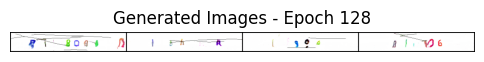

[128/200][0/157]	Loss_D: 0.8631	Loss_G: 1.3255	D(x): 0.8158	D(G(z)): 0.4404 / 0.3019
[128/200][50/157]	Loss_D: 1.1389	Loss_G: 0.8036	D(x): 0.4005	D(G(z)): 0.0921 / 0.4773
[128/200][100/157]	Loss_D: 1.0577	Loss_G: 0.9010	D(x): 0.5026	D(G(z)): 0.2374 / 0.4327
[128/200][150/157]	Loss_D: 1.1348	Loss_G: 0.3944	D(x): 0.3994	D(G(z)): 0.1149 / 0.6939


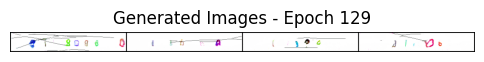

[129/200][0/157]	Loss_D: 0.9652	Loss_G: 1.4901	D(x): 0.7974	D(G(z)): 0.4717 / 0.2656
[129/200][50/157]	Loss_D: 1.3507	Loss_G: 2.6241	D(x): 0.8925	D(G(z)): 0.6731 / 0.0992
[129/200][100/157]	Loss_D: 1.2134	Loss_G: 0.5508	D(x): 0.4007	D(G(z)): 0.1122 / 0.6130
[129/200][150/157]	Loss_D: 0.8518	Loss_G: 0.9605	D(x): 0.6016	D(G(z)): 0.2440 / 0.3992


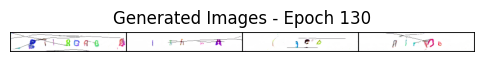

[130/200][0/157]	Loss_D: 0.6844	Loss_G: 0.6161	D(x): 0.7114	D(G(z)): 0.2610 / 0.5851
[130/200][50/157]	Loss_D: 1.5576	Loss_G: 0.2546	D(x): 0.2906	D(G(z)): 0.0978 / 0.7928
[130/200][100/157]	Loss_D: 0.7719	Loss_G: 1.4537	D(x): 0.6313	D(G(z)): 0.2262 / 0.2872
[130/200][150/157]	Loss_D: 1.0420	Loss_G: 2.0835	D(x): 0.8570	D(G(z)): 0.5588 / 0.1556


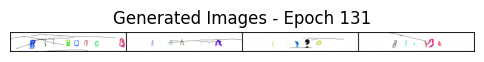

[131/200][0/157]	Loss_D: 0.7056	Loss_G: 1.3180	D(x): 0.7062	D(G(z)): 0.2567 / 0.3269
[131/200][50/157]	Loss_D: 0.7649	Loss_G: 1.7308	D(x): 0.7282	D(G(z)): 0.3225 / 0.2093
[131/200][100/157]	Loss_D: 1.0741	Loss_G: 0.7579	D(x): 0.4608	D(G(z)): 0.1644 / 0.4996
[131/200][150/157]	Loss_D: 0.8781	Loss_G: 0.9459	D(x): 0.5656	D(G(z)): 0.2120 / 0.4237


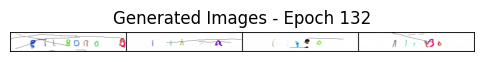

[132/200][0/157]	Loss_D: 0.8370	Loss_G: 3.3783	D(x): 0.9038	D(G(z)): 0.4849 / 0.0502
[132/200][50/157]	Loss_D: 0.7454	Loss_G: 0.9819	D(x): 0.6304	D(G(z)): 0.2069 / 0.4148
[132/200][100/157]	Loss_D: 0.6310	Loss_G: 1.3812	D(x): 0.6435	D(G(z)): 0.1395 / 0.2964
[132/200][150/157]	Loss_D: 0.9203	Loss_G: 1.0499	D(x): 0.6165	D(G(z)): 0.3011 / 0.3929


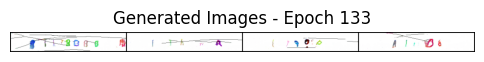

[133/200][0/157]	Loss_D: 0.6472	Loss_G: 1.4297	D(x): 0.6915	D(G(z)): 0.2053 / 0.2996
[133/200][50/157]	Loss_D: 0.7613	Loss_G: 1.2386	D(x): 0.7207	D(G(z)): 0.3126 / 0.3318
[133/200][100/157]	Loss_D: 0.9057	Loss_G: 0.9106	D(x): 0.5375	D(G(z)): 0.1898 / 0.4226
[133/200][150/157]	Loss_D: 0.9363	Loss_G: 2.1683	D(x): 0.8481	D(G(z)): 0.4904 / 0.1386


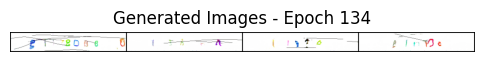

[134/200][0/157]	Loss_D: 0.6741	Loss_G: 1.5925	D(x): 0.6400	D(G(z)): 0.1509 / 0.2538
[134/200][50/157]	Loss_D: 0.7085	Loss_G: 2.0105	D(x): 0.7895	D(G(z)): 0.3443 / 0.1635
[134/200][100/157]	Loss_D: 0.7261	Loss_G: 0.9123	D(x): 0.6171	D(G(z)): 0.1656 / 0.4614
[134/200][150/157]	Loss_D: 0.6512	Loss_G: 1.1839	D(x): 0.7255	D(G(z)): 0.2479 / 0.3396


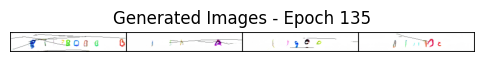

[135/200][0/157]	Loss_D: 0.6564	Loss_G: 1.2847	D(x): 0.7829	D(G(z)): 0.3131 / 0.3171
[135/200][50/157]	Loss_D: 0.6771	Loss_G: 1.3855	D(x): 0.6965	D(G(z)): 0.2306 / 0.3077
[135/200][100/157]	Loss_D: 0.8731	Loss_G: 2.2016	D(x): 0.8242	D(G(z)): 0.4587 / 0.1443
[135/200][150/157]	Loss_D: 0.9120	Loss_G: 1.6048	D(x): 0.7962	D(G(z)): 0.4595 / 0.2412


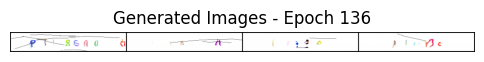

[136/200][0/157]	Loss_D: 0.8406	Loss_G: 1.4310	D(x): 0.7699	D(G(z)): 0.4039 / 0.2651
[136/200][50/157]	Loss_D: 0.6810	Loss_G: 1.0701	D(x): 0.6408	D(G(z)): 0.1734 / 0.3882
[136/200][100/157]	Loss_D: 0.7642	Loss_G: 1.0076	D(x): 0.5723	D(G(z)): 0.1330 / 0.4197
[136/200][150/157]	Loss_D: 0.6192	Loss_G: 1.5964	D(x): 0.7698	D(G(z)): 0.2749 / 0.2525


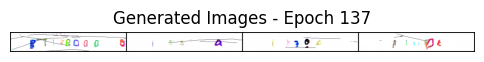

[137/200][0/157]	Loss_D: 0.7398	Loss_G: 1.2349	D(x): 0.6268	D(G(z)): 0.1976 / 0.3482
[137/200][50/157]	Loss_D: 1.1026	Loss_G: 2.8021	D(x): 0.8877	D(G(z)): 0.5890 / 0.0828
[137/200][100/157]	Loss_D: 0.8383	Loss_G: 1.8823	D(x): 0.7435	D(G(z)): 0.3802 / 0.1972
[137/200][150/157]	Loss_D: 0.9995	Loss_G: 1.0803	D(x): 0.5251	D(G(z)): 0.2515 / 0.3920


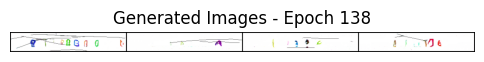

[138/200][0/157]	Loss_D: 0.9183	Loss_G: 2.0357	D(x): 0.7875	D(G(z)): 0.4579 / 0.1600
[138/200][50/157]	Loss_D: 0.9291	Loss_G: 1.5293	D(x): 0.7137	D(G(z)): 0.4084 / 0.2603
[138/200][100/157]	Loss_D: 1.0358	Loss_G: 1.5613	D(x): 0.6925	D(G(z)): 0.4299 / 0.2635
[138/200][150/157]	Loss_D: 0.7516	Loss_G: 1.0868	D(x): 0.6120	D(G(z)): 0.1856 / 0.4148


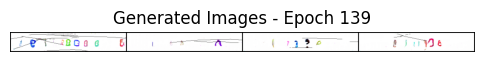

[139/200][0/157]	Loss_D: 0.6677	Loss_G: 1.7146	D(x): 0.7412	D(G(z)): 0.2636 / 0.2127
[139/200][50/157]	Loss_D: 0.6592	Loss_G: 1.1846	D(x): 0.7129	D(G(z)): 0.2478 / 0.3510
[139/200][100/157]	Loss_D: 1.0428	Loss_G: 1.9451	D(x): 0.8427	D(G(z)): 0.5273 / 0.1764
[139/200][150/157]	Loss_D: 0.7499	Loss_G: 1.1797	D(x): 0.6824	D(G(z)): 0.2636 / 0.3505


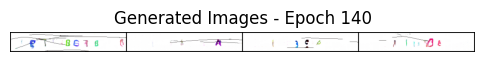

[140/200][0/157]	Loss_D: 0.6350	Loss_G: 1.1346	D(x): 0.7038	D(G(z)): 0.2105 / 0.3644
[140/200][50/157]	Loss_D: 0.7347	Loss_G: 2.6197	D(x): 0.8711	D(G(z)): 0.4233 / 0.1025
[140/200][100/157]	Loss_D: 0.9136	Loss_G: 1.0315	D(x): 0.5229	D(G(z)): 0.1793 / 0.3931
[140/200][150/157]	Loss_D: 0.7013	Loss_G: 1.3330	D(x): 0.6334	D(G(z)): 0.1693 / 0.3071


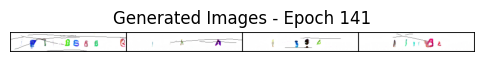

[141/200][0/157]	Loss_D: 0.8497	Loss_G: 2.0387	D(x): 0.7307	D(G(z)): 0.3722 / 0.1660
[141/200][50/157]	Loss_D: 0.8345	Loss_G: 0.9402	D(x): 0.6021	D(G(z)): 0.2249 / 0.4389
[141/200][100/157]	Loss_D: 0.5826	Loss_G: 1.2086	D(x): 0.7574	D(G(z)): 0.2303 / 0.3295
[141/200][150/157]	Loss_D: 0.7897	Loss_G: 1.6030	D(x): 0.6868	D(G(z)): 0.2669 / 0.2302


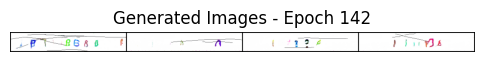

[142/200][0/157]	Loss_D: 0.7646	Loss_G: 1.6292	D(x): 0.8667	D(G(z)): 0.4296 / 0.2454
[142/200][50/157]	Loss_D: 0.8266	Loss_G: 0.8873	D(x): 0.5555	D(G(z)): 0.1385 / 0.4461
[142/200][100/157]	Loss_D: 1.0948	Loss_G: 0.6480	D(x): 0.4166	D(G(z)): 0.0746 / 0.5663
[142/200][150/157]	Loss_D: 0.7648	Loss_G: 2.3568	D(x): 0.8115	D(G(z)): 0.3834 / 0.1255


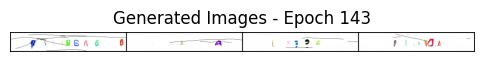

[143/200][0/157]	Loss_D: 1.8114	Loss_G: 3.0651	D(x): 0.9680	D(G(z)): 0.7888 / 0.0729
[143/200][50/157]	Loss_D: 0.8159	Loss_G: 1.5811	D(x): 0.7707	D(G(z)): 0.3741 / 0.2583
[143/200][100/157]	Loss_D: 0.9453	Loss_G: 0.6373	D(x): 0.4936	D(G(z)): 0.1273 / 0.5769
[143/200][150/157]	Loss_D: 0.9069	Loss_G: 1.5470	D(x): 0.8809	D(G(z)): 0.5027 / 0.2374


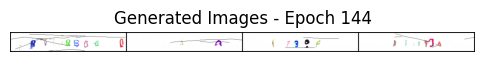

[144/200][0/157]	Loss_D: 0.9782	Loss_G: 2.5489	D(x): 0.9341	D(G(z)): 0.5583 / 0.1085
[144/200][50/157]	Loss_D: 0.6669	Loss_G: 2.4847	D(x): 0.8700	D(G(z)): 0.3799 / 0.1116
[144/200][100/157]	Loss_D: 0.6582	Loss_G: 2.2180	D(x): 0.7739	D(G(z)): 0.3073 / 0.1391
[144/200][150/157]	Loss_D: 1.3350	Loss_G: 0.8001	D(x): 0.3111	D(G(z)): 0.0377 / 0.4990


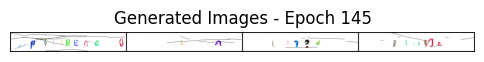

[145/200][0/157]	Loss_D: 0.8007	Loss_G: 1.4449	D(x): 0.6563	D(G(z)): 0.2623 / 0.3109
[145/200][50/157]	Loss_D: 0.8106	Loss_G: 0.9366	D(x): 0.6024	D(G(z)): 0.2071 / 0.4419
[145/200][100/157]	Loss_D: 0.6603	Loss_G: 1.6507	D(x): 0.7972	D(G(z)): 0.3182 / 0.2315
[145/200][150/157]	Loss_D: 0.5432	Loss_G: 1.8665	D(x): 0.7993	D(G(z)): 0.2497 / 0.1974


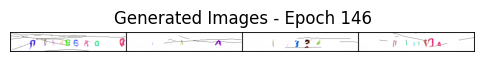

[146/200][0/157]	Loss_D: 1.2569	Loss_G: 0.6024	D(x): 0.3763	D(G(z)): 0.1025 / 0.6510
[146/200][50/157]	Loss_D: 0.7519	Loss_G: 2.1858	D(x): 0.7879	D(G(z)): 0.3627 / 0.1601
[146/200][100/157]	Loss_D: 0.6521	Loss_G: 2.0082	D(x): 0.8123	D(G(z)): 0.3345 / 0.1738
[146/200][150/157]	Loss_D: 0.7440	Loss_G: 1.0028	D(x): 0.6143	D(G(z)): 0.1756 / 0.4155


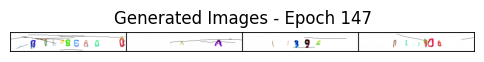

[147/200][0/157]	Loss_D: 0.7064	Loss_G: 2.2279	D(x): 0.7657	D(G(z)): 0.3176 / 0.1406
[147/200][50/157]	Loss_D: 1.0065	Loss_G: 2.3284	D(x): 0.7919	D(G(z)): 0.5008 / 0.1267
[147/200][100/157]	Loss_D: 0.6842	Loss_G: 2.4490	D(x): 0.8992	D(G(z)): 0.4058 / 0.1044
[147/200][150/157]	Loss_D: 1.0868	Loss_G: 3.0770	D(x): 0.9426	D(G(z)): 0.5894 / 0.0615


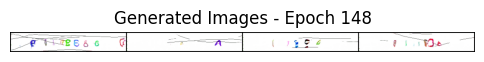

[148/200][0/157]	Loss_D: 0.8021	Loss_G: 0.8313	D(x): 0.6640	D(G(z)): 0.2583 / 0.4769
[148/200][50/157]	Loss_D: 0.5304	Loss_G: 2.4668	D(x): 0.7997	D(G(z)): 0.2438 / 0.1200
[148/200][100/157]	Loss_D: 0.7152	Loss_G: 2.1423	D(x): 0.8457	D(G(z)): 0.3731 / 0.1643
[148/200][150/157]	Loss_D: 0.9999	Loss_G: 0.6719	D(x): 0.4807	D(G(z)): 0.1492 / 0.5516


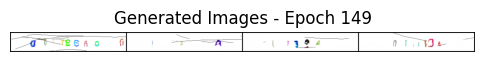

[149/200][0/157]	Loss_D: 2.5791	Loss_G: 4.1101	D(x): 0.9882	D(G(z)): 0.8955 / 0.0314
[149/200][50/157]	Loss_D: 1.4818	Loss_G: 2.8730	D(x): 0.7749	D(G(z)): 0.6389 / 0.0867
[149/200][100/157]	Loss_D: 0.6674	Loss_G: 1.2225	D(x): 0.7332	D(G(z)): 0.2625 / 0.3407
[149/200][150/157]	Loss_D: 0.8188	Loss_G: 2.0943	D(x): 0.7354	D(G(z)): 0.3640 / 0.1702


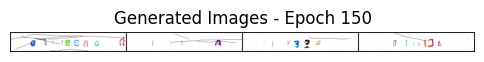

[150/200][0/157]	Loss_D: 0.6242	Loss_G: 2.4577	D(x): 0.8110	D(G(z)): 0.3070 / 0.1224
[150/200][50/157]	Loss_D: 0.6622	Loss_G: 1.5981	D(x): 0.6857	D(G(z)): 0.2108 / 0.2377
[150/200][100/157]	Loss_D: 0.7644	Loss_G: 0.8325	D(x): 0.6098	D(G(z)): 0.1870 / 0.5170
[150/200][150/157]	Loss_D: 1.9714	Loss_G: 0.5358	D(x): 0.1776	D(G(z)): 0.0240 / 0.6225


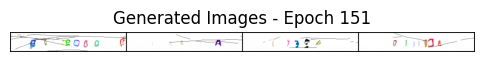

[151/200][0/157]	Loss_D: 0.7899	Loss_G: 2.0590	D(x): 0.8434	D(G(z)): 0.4153 / 0.1646
[151/200][50/157]	Loss_D: 0.5285	Loss_G: 2.1869	D(x): 0.7859	D(G(z)): 0.2220 / 0.1567
[151/200][100/157]	Loss_D: 0.7498	Loss_G: 1.5700	D(x): 0.7279	D(G(z)): 0.3068 / 0.2435
[151/200][150/157]	Loss_D: 1.7425	Loss_G: 0.5701	D(x): 0.2389	D(G(z)): 0.0414 / 0.6148


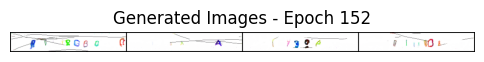

[152/200][0/157]	Loss_D: 1.2710	Loss_G: 0.6776	D(x): 0.3800	D(G(z)): 0.1180 / 0.5672
[152/200][50/157]	Loss_D: 0.8864	Loss_G: 2.7249	D(x): 0.8019	D(G(z)): 0.4253 / 0.0917
[152/200][100/157]	Loss_D: 0.8352	Loss_G: 1.1943	D(x): 0.6547	D(G(z)): 0.2951 / 0.3668
[152/200][150/157]	Loss_D: 0.8575	Loss_G: 2.6068	D(x): 0.9240	D(G(z)): 0.4988 / 0.0903


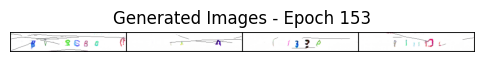

[153/200][0/157]	Loss_D: 0.5650	Loss_G: 1.9679	D(x): 0.7714	D(G(z)): 0.2289 / 0.1817
[153/200][50/157]	Loss_D: 0.7105	Loss_G: 1.2648	D(x): 0.6201	D(G(z)): 0.1563 / 0.3546
[153/200][100/157]	Loss_D: 1.2988	Loss_G: 0.7124	D(x): 0.3451	D(G(z)): 0.0463 / 0.5294
[153/200][150/157]	Loss_D: 0.7695	Loss_G: 1.3618	D(x): 0.5955	D(G(z)): 0.1669 / 0.3515


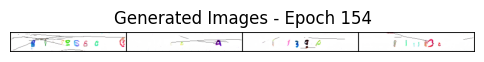

[154/200][0/157]	Loss_D: 0.6982	Loss_G: 1.5651	D(x): 0.7497	D(G(z)): 0.2825 / 0.2633
[154/200][50/157]	Loss_D: 1.0835	Loss_G: 3.2735	D(x): 0.8777	D(G(z)): 0.5560 / 0.0598
[154/200][100/157]	Loss_D: 0.7504	Loss_G: 0.8099	D(x): 0.6643	D(G(z)): 0.2441 / 0.4960
[154/200][150/157]	Loss_D: 0.9455	Loss_G: 0.6556	D(x): 0.4655	D(G(z)): 0.0848 / 0.5715


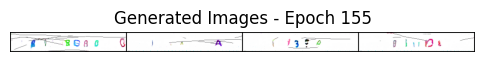

[155/200][0/157]	Loss_D: 0.6959	Loss_G: 1.2657	D(x): 0.7152	D(G(z)): 0.2570 / 0.3326
[155/200][50/157]	Loss_D: 0.6215	Loss_G: 0.6416	D(x): 0.6406	D(G(z)): 0.1182 / 0.5736
[155/200][100/157]	Loss_D: 0.9716	Loss_G: 0.9082	D(x): 0.4758	D(G(z)): 0.1194 / 0.4553
[155/200][150/157]	Loss_D: 0.6215	Loss_G: 1.3711	D(x): 0.7472	D(G(z)): 0.2541 / 0.3069


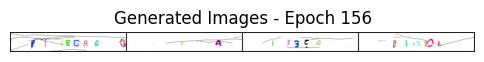

[156/200][0/157]	Loss_D: 0.6660	Loss_G: 1.6862	D(x): 0.7607	D(G(z)): 0.2925 / 0.2372
[156/200][50/157]	Loss_D: 0.6871	Loss_G: 1.2826	D(x): 0.6998	D(G(z)): 0.2357 / 0.3173
[156/200][100/157]	Loss_D: 1.1621	Loss_G: 2.7359	D(x): 0.9196	D(G(z)): 0.5947 / 0.0992
[156/200][150/157]	Loss_D: 1.2020	Loss_G: 0.7201	D(x): 0.3740	D(G(z)): 0.0519 / 0.5371


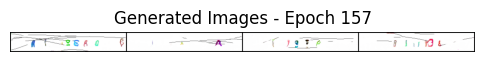

[157/200][0/157]	Loss_D: 0.7837	Loss_G: 2.2194	D(x): 0.9067	D(G(z)): 0.4542 / 0.1452
[157/200][50/157]	Loss_D: 0.6871	Loss_G: 2.0321	D(x): 0.8509	D(G(z)): 0.3697 / 0.1819
[157/200][100/157]	Loss_D: 0.6803	Loss_G: 2.0946	D(x): 0.9112	D(G(z)): 0.4120 / 0.1712
[157/200][150/157]	Loss_D: 0.6522	Loss_G: 1.4662	D(x): 0.7151	D(G(z)): 0.2347 / 0.2719


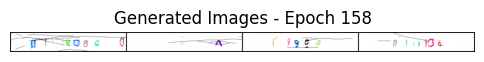

[158/200][0/157]	Loss_D: 0.6755	Loss_G: 2.6475	D(x): 0.7719	D(G(z)): 0.3021 / 0.1048
[158/200][50/157]	Loss_D: 1.1665	Loss_G: 0.4010	D(x): 0.3931	D(G(z)): 0.0804 / 0.7130
[158/200][100/157]	Loss_D: 0.6946	Loss_G: 2.1056	D(x): 0.7763	D(G(z)): 0.3145 / 0.1544
[158/200][150/157]	Loss_D: 0.8781	Loss_G: 1.0447	D(x): 0.5048	D(G(z)): 0.0631 / 0.4269


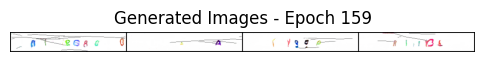

[159/200][0/157]	Loss_D: 1.2139	Loss_G: 3.1510	D(x): 0.9351	D(G(z)): 0.6246 / 0.0777
[159/200][50/157]	Loss_D: 0.7359	Loss_G: 1.3338	D(x): 0.6750	D(G(z)): 0.2280 / 0.3340
[159/200][100/157]	Loss_D: 0.7957	Loss_G: 2.4474	D(x): 0.8328	D(G(z)): 0.4127 / 0.1119
[159/200][150/157]	Loss_D: 0.5863	Loss_G: 1.5305	D(x): 0.8107	D(G(z)): 0.2770 / 0.2633


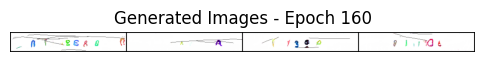

[160/200][0/157]	Loss_D: 0.7029	Loss_G: 1.7561	D(x): 0.6012	D(G(z)): 0.1260 / 0.2255
[160/200][50/157]	Loss_D: 0.7016	Loss_G: 3.3405	D(x): 0.8756	D(G(z)): 0.3957 / 0.0537
[160/200][100/157]	Loss_D: 0.9363	Loss_G: 1.1627	D(x): 0.4624	D(G(z)): 0.0485 / 0.3592
[160/200][150/157]	Loss_D: 0.6930	Loss_G: 1.0925	D(x): 0.6700	D(G(z)): 0.1989 / 0.3942


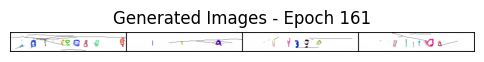

[161/200][0/157]	Loss_D: 0.6242	Loss_G: 1.4954	D(x): 0.6836	D(G(z)): 0.1747 / 0.2728
[161/200][50/157]	Loss_D: 0.7154	Loss_G: 0.9782	D(x): 0.5901	D(G(z)): 0.1089 / 0.4282
[161/200][100/157]	Loss_D: 0.9009	Loss_G: 1.1875	D(x): 0.5021	D(G(z)): 0.1030 / 0.3632
[161/200][150/157]	Loss_D: 0.8239	Loss_G: 0.7518	D(x): 0.5679	D(G(z)): 0.1642 / 0.5058


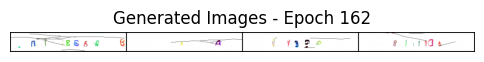

[162/200][0/157]	Loss_D: 0.4726	Loss_G: 1.5271	D(x): 0.8122	D(G(z)): 0.2159 / 0.2633
[162/200][50/157]	Loss_D: 0.6743	Loss_G: 1.0826	D(x): 0.6070	D(G(z)): 0.1119 / 0.3989
[162/200][100/157]	Loss_D: 0.6572	Loss_G: 2.8352	D(x): 0.8504	D(G(z)): 0.3560 / 0.0853
[162/200][150/157]	Loss_D: 0.8183	Loss_G: 2.4094	D(x): 0.9178	D(G(z)): 0.4748 / 0.1279


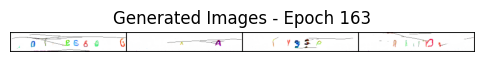

[163/200][0/157]	Loss_D: 0.5078	Loss_G: 1.9090	D(x): 0.7564	D(G(z)): 0.1683 / 0.1950
[163/200][50/157]	Loss_D: 0.7538	Loss_G: 2.4177	D(x): 0.8564	D(G(z)): 0.4052 / 0.1389
[163/200][100/157]	Loss_D: 0.8517	Loss_G: 0.8656	D(x): 0.5357	D(G(z)): 0.1155 / 0.4684
[163/200][150/157]	Loss_D: 1.1605	Loss_G: 3.0738	D(x): 0.8805	D(G(z)): 0.5736 / 0.0608


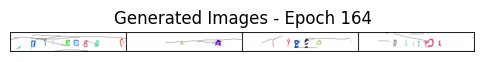

[164/200][0/157]	Loss_D: 1.0885	Loss_G: 2.7685	D(x): 0.9426	D(G(z)): 0.5992 / 0.0833
[164/200][50/157]	Loss_D: 0.5638	Loss_G: 2.7040	D(x): 0.8398	D(G(z)): 0.2985 / 0.1009
[164/200][100/157]	Loss_D: 0.8378	Loss_G: 0.7790	D(x): 0.5047	D(G(z)): 0.0636 / 0.5177
[164/200][150/157]	Loss_D: 0.6788	Loss_G: 1.0929	D(x): 0.6159	D(G(z)): 0.1152 / 0.4106


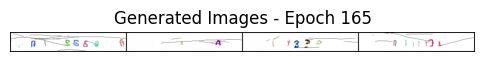

[165/200][0/157]	Loss_D: 1.0046	Loss_G: 3.6300	D(x): 0.9288	D(G(z)): 0.5484 / 0.0405
[165/200][50/157]	Loss_D: 0.5684	Loss_G: 2.5027	D(x): 0.8168	D(G(z)): 0.2739 / 0.1224
[165/200][100/157]	Loss_D: 1.1375	Loss_G: 3.0457	D(x): 0.9246	D(G(z)): 0.5961 / 0.0745
[165/200][150/157]	Loss_D: 1.1856	Loss_G: 3.6973	D(x): 0.9358	D(G(z)): 0.6344 / 0.0406


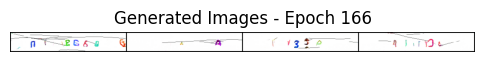

[166/200][0/157]	Loss_D: 0.6714	Loss_G: 1.6744	D(x): 0.6594	D(G(z)): 0.1591 / 0.2388
[166/200][50/157]	Loss_D: 0.7172	Loss_G: 1.8382	D(x): 0.7176	D(G(z)): 0.2741 / 0.1977
[166/200][100/157]	Loss_D: 0.7271	Loss_G: 2.8481	D(x): 0.8800	D(G(z)): 0.4076 / 0.0915
[166/200][150/157]	Loss_D: 0.5250	Loss_G: 1.3696	D(x): 0.6865	D(G(z)): 0.1087 / 0.3221


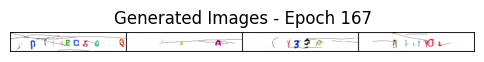

[167/200][0/157]	Loss_D: 0.6445	Loss_G: 2.7637	D(x): 0.8229	D(G(z)): 0.3038 / 0.0927
[167/200][50/157]	Loss_D: 0.6726	Loss_G: 1.6385	D(x): 0.6597	D(G(z)): 0.1807 / 0.2560
[167/200][100/157]	Loss_D: 0.6060	Loss_G: 1.4724	D(x): 0.7524	D(G(z)): 0.2365 / 0.2737
[167/200][150/157]	Loss_D: 1.0496	Loss_G: 0.9305	D(x): 0.4391	D(G(z)): 0.0436 / 0.4512


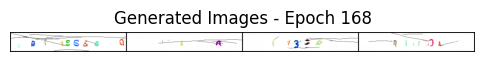

[168/200][0/157]	Loss_D: 0.8242	Loss_G: 1.2608	D(x): 0.5120	D(G(z)): 0.0515 / 0.3783
[168/200][50/157]	Loss_D: 0.5592	Loss_G: 1.9886	D(x): 0.7724	D(G(z)): 0.2200 / 0.1908
[168/200][100/157]	Loss_D: 0.6810	Loss_G: 1.5133	D(x): 0.6249	D(G(z)): 0.1285 / 0.3025
[168/200][150/157]	Loss_D: 0.6040	Loss_G: 1.8663	D(x): 0.6346	D(G(z)): 0.0914 / 0.1867


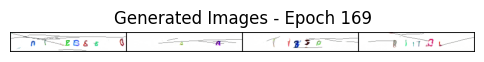

[169/200][0/157]	Loss_D: 0.5160	Loss_G: 1.3239	D(x): 0.8001	D(G(z)): 0.2249 / 0.3364
[169/200][50/157]	Loss_D: 0.5483	Loss_G: 2.0930	D(x): 0.8164	D(G(z)): 0.2610 / 0.1680
[169/200][100/157]	Loss_D: 0.6195	Loss_G: 2.2578	D(x): 0.8172	D(G(z)): 0.3086 / 0.1462
[169/200][150/157]	Loss_D: 0.5898	Loss_G: 1.5074	D(x): 0.7495	D(G(z)): 0.2188 / 0.3155


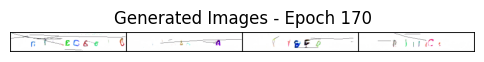

[170/200][0/157]	Loss_D: 0.7204	Loss_G: 2.1911	D(x): 0.8816	D(G(z)): 0.4008 / 0.1459
[170/200][50/157]	Loss_D: 0.9808	Loss_G: 2.1408	D(x): 0.7782	D(G(z)): 0.4672 / 0.1746
[170/200][100/157]	Loss_D: 0.7509	Loss_G: 2.9283	D(x): 0.9452	D(G(z)): 0.4602 / 0.0830
[170/200][150/157]	Loss_D: 0.6128	Loss_G: 2.6743	D(x): 0.8323	D(G(z)): 0.3196 / 0.1060


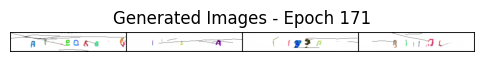

[171/200][0/157]	Loss_D: 1.3794	Loss_G: 3.0289	D(x): 0.9679	D(G(z)): 0.6566 / 0.0831
[171/200][50/157]	Loss_D: 0.5918	Loss_G: 1.5770	D(x): 0.7339	D(G(z)): 0.1972 / 0.2730
[171/200][100/157]	Loss_D: 0.5358	Loss_G: 1.7428	D(x): 0.8266	D(G(z)): 0.2669 / 0.2348
[171/200][150/157]	Loss_D: 1.1032	Loss_G: 0.8230	D(x): 0.4166	D(G(z)): 0.0462 / 0.5048


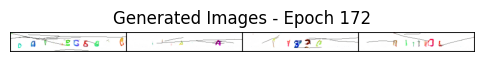

[172/200][0/157]	Loss_D: 0.5750	Loss_G: 2.1151	D(x): 0.7655	D(G(z)): 0.2339 / 0.2135
[172/200][50/157]	Loss_D: 0.5745	Loss_G: 2.0686	D(x): 0.8847	D(G(z)): 0.3360 / 0.1725
[172/200][100/157]	Loss_D: 1.2070	Loss_G: 0.8058	D(x): 0.3602	D(G(z)): 0.0333 / 0.5082
[172/200][150/157]	Loss_D: 0.6311	Loss_G: 1.6496	D(x): 0.8416	D(G(z)): 0.3321 / 0.2337


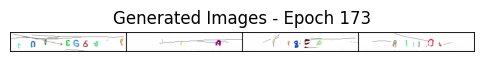

[173/200][0/157]	Loss_D: 0.9373	Loss_G: 1.5833	D(x): 0.4584	D(G(z)): 0.0544 / 0.2741
[173/200][50/157]	Loss_D: 0.6169	Loss_G: 2.8650	D(x): 0.8268	D(G(z)): 0.3088 / 0.0985
[173/200][100/157]	Loss_D: 1.2156	Loss_G: 0.9211	D(x): 0.3504	D(G(z)): 0.0356 / 0.4513
[173/200][150/157]	Loss_D: 0.6091	Loss_G: 1.0391	D(x): 0.6583	D(G(z)): 0.1164 / 0.4003


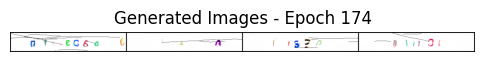

[174/200][0/157]	Loss_D: 1.4792	Loss_G: 3.7027	D(x): 0.9754	D(G(z)): 0.6955 / 0.0389
[174/200][50/157]	Loss_D: 0.5435	Loss_G: 2.0451	D(x): 0.7367	D(G(z)): 0.1758 / 0.1677
[174/200][100/157]	Loss_D: 0.5320	Loss_G: 1.5127	D(x): 0.7032	D(G(z)): 0.1209 / 0.2728
[174/200][150/157]	Loss_D: 0.7053	Loss_G: 3.0946	D(x): 0.9215	D(G(z)): 0.4367 / 0.0652


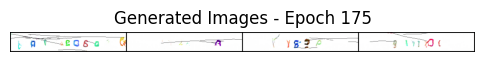

[175/200][0/157]	Loss_D: 0.4101	Loss_G: 1.4300	D(x): 0.8202	D(G(z)): 0.1657 / 0.3113
[175/200][50/157]	Loss_D: 0.6746	Loss_G: 1.1188	D(x): 0.6292	D(G(z)): 0.1241 / 0.3859
[175/200][100/157]	Loss_D: 0.6309	Loss_G: 2.2867	D(x): 0.8597	D(G(z)): 0.3426 / 0.1295
[175/200][150/157]	Loss_D: 0.8334	Loss_G: 2.2531	D(x): 0.8494	D(G(z)): 0.4242 / 0.1606


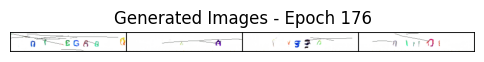

[176/200][0/157]	Loss_D: 1.5136	Loss_G: 3.9051	D(x): 0.9652	D(G(z)): 0.7080 / 0.0301
[176/200][50/157]	Loss_D: 0.6691	Loss_G: 1.5559	D(x): 0.5860	D(G(z)): 0.0726 / 0.2639
[176/200][100/157]	Loss_D: 0.8826	Loss_G: 3.4404	D(x): 0.9152	D(G(z)): 0.5016 / 0.0544
[176/200][150/157]	Loss_D: 1.0977	Loss_G: 3.6986	D(x): 0.9570	D(G(z)): 0.6030 / 0.0427


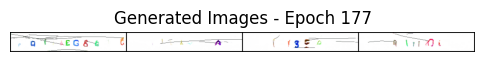

[177/200][0/157]	Loss_D: 0.8230	Loss_G: 0.6838	D(x): 0.5070	D(G(z)): 0.0542 / 0.5813
[177/200][50/157]	Loss_D: 0.6683	Loss_G: 1.9330	D(x): 0.8560	D(G(z)): 0.3488 / 0.1990
[177/200][100/157]	Loss_D: 0.6886	Loss_G: 3.3700	D(x): 0.9394	D(G(z)): 0.4189 / 0.0508
[177/200][150/157]	Loss_D: 0.5715	Loss_G: 1.4474	D(x): 0.6609	D(G(z)): 0.1002 / 0.2855


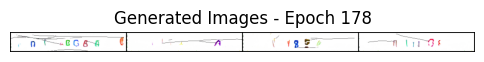

[178/200][0/157]	Loss_D: 0.6118	Loss_G: 0.9023	D(x): 0.6641	D(G(z)): 0.1190 / 0.4826
[178/200][50/157]	Loss_D: 0.6282	Loss_G: 3.3571	D(x): 0.9126	D(G(z)): 0.3772 / 0.0486
[178/200][100/157]	Loss_D: 0.5508	Loss_G: 2.1626	D(x): 0.8071	D(G(z)): 0.2529 / 0.1582
[178/200][150/157]	Loss_D: 0.4820	Loss_G: 2.4745	D(x): 0.9007	D(G(z)): 0.2805 / 0.1301


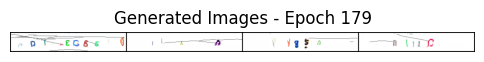

[179/200][0/157]	Loss_D: 0.7561	Loss_G: 1.1078	D(x): 0.5843	D(G(z)): 0.1097 / 0.3835
[179/200][50/157]	Loss_D: 0.4325	Loss_G: 1.6416	D(x): 0.7996	D(G(z)): 0.1657 / 0.2415
[179/200][100/157]	Loss_D: 0.5678	Loss_G: 1.3927	D(x): 0.7264	D(G(z)): 0.1862 / 0.3071
[179/200][150/157]	Loss_D: 0.5684	Loss_G: 1.6064	D(x): 0.8242	D(G(z)): 0.2757 / 0.2611


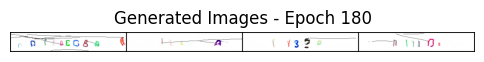

[180/200][0/157]	Loss_D: 0.8764	Loss_G: 4.7585	D(x): 0.9146	D(G(z)): 0.4880 / 0.0137
[180/200][50/157]	Loss_D: 0.5494	Loss_G: 1.1866	D(x): 0.6554	D(G(z)): 0.0752 / 0.3641
[180/200][100/157]	Loss_D: 0.6257	Loss_G: 2.1129	D(x): 0.6694	D(G(z)): 0.1130 / 0.1673
[180/200][150/157]	Loss_D: 1.3592	Loss_G: 0.7879	D(x): 0.3233	D(G(z)): 0.0426 / 0.5021


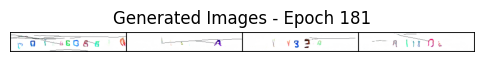

[181/200][0/157]	Loss_D: 0.7463	Loss_G: 3.8352	D(x): 0.9237	D(G(z)): 0.4346 / 0.0420
[181/200][50/157]	Loss_D: 0.7041	Loss_G: 3.6611	D(x): 0.9160	D(G(z)): 0.4197 / 0.0536
[181/200][100/157]	Loss_D: 0.6876	Loss_G: 1.0457	D(x): 0.6060	D(G(z)): 0.0991 / 0.4059
[181/200][150/157]	Loss_D: 0.6642	Loss_G: 2.1542	D(x): 0.9042	D(G(z)): 0.3914 / 0.1592


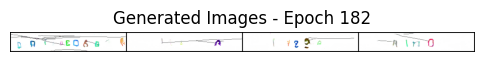

[182/200][0/157]	Loss_D: 0.3984	Loss_G: 2.1774	D(x): 0.8425	D(G(z)): 0.1819 / 0.1443
[182/200][50/157]	Loss_D: 0.5222	Loss_G: 2.4682	D(x): 0.7451	D(G(z)): 0.1755 / 0.1452
[182/200][100/157]	Loss_D: 0.7954	Loss_G: 3.9051	D(x): 0.9331	D(G(z)): 0.4688 / 0.0393
[182/200][150/157]	Loss_D: 0.5441	Loss_G: 2.0367	D(x): 0.7093	D(G(z)): 0.1324 / 0.1783


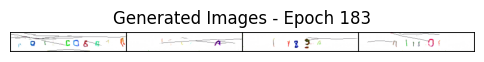

[183/200][0/157]	Loss_D: 0.5141	Loss_G: 3.7677	D(x): 0.9398	D(G(z)): 0.3378 / 0.0342
[183/200][50/157]	Loss_D: 0.3283	Loss_G: 2.4740	D(x): 0.8852	D(G(z)): 0.1622 / 0.1234
[183/200][100/157]	Loss_D: 0.5535	Loss_G: 2.2843	D(x): 0.8902	D(G(z)): 0.3245 / 0.1401
[183/200][150/157]	Loss_D: 1.1658	Loss_G: 3.3187	D(x): 0.9488	D(G(z)): 0.6195 / 0.0555


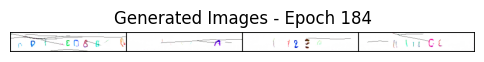

[184/200][0/157]	Loss_D: 1.0128	Loss_G: 3.5439	D(x): 0.9167	D(G(z)): 0.5022 / 0.0554
[184/200][50/157]	Loss_D: 0.7332	Loss_G: 0.9330	D(x): 0.5599	D(G(z)): 0.0328 / 0.4975
[184/200][100/157]	Loss_D: 0.3915	Loss_G: 1.3171	D(x): 0.8031	D(G(z)): 0.1343 / 0.3472
[184/200][150/157]	Loss_D: 0.5559	Loss_G: 1.6588	D(x): 0.6812	D(G(z)): 0.1142 / 0.2648


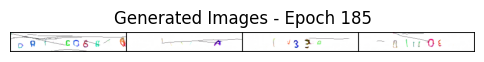

[185/200][0/157]	Loss_D: 1.1477	Loss_G: 3.5660	D(x): 0.9625	D(G(z)): 0.6222 / 0.0414
[185/200][50/157]	Loss_D: 0.5472	Loss_G: 1.8393	D(x): 0.8144	D(G(z)): 0.2518 / 0.2228
[185/200][100/157]	Loss_D: 0.4399	Loss_G: 1.4763	D(x): 0.7683	D(G(z)): 0.1394 / 0.2807
[185/200][150/157]	Loss_D: 0.6378	Loss_G: 1.0473	D(x): 0.6725	D(G(z)): 0.1535 / 0.4369


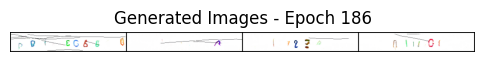

[186/200][0/157]	Loss_D: 0.9739	Loss_G: 3.8671	D(x): 0.9621	D(G(z)): 0.5489 / 0.0335
[186/200][50/157]	Loss_D: 0.6287	Loss_G: 1.1561	D(x): 0.6403	D(G(z)): 0.1131 / 0.3805
[186/200][100/157]	Loss_D: 0.4394	Loss_G: 1.9854	D(x): 0.8711	D(G(z)): 0.2263 / 0.1785
[186/200][150/157]	Loss_D: 0.5309	Loss_G: 2.5294	D(x): 0.9219	D(G(z)): 0.3343 / 0.1116


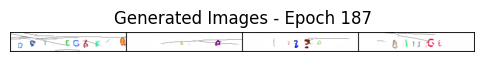

[187/200][0/157]	Loss_D: 0.5338	Loss_G: 3.6812	D(x): 0.9221	D(G(z)): 0.3306 / 0.0468
[187/200][50/157]	Loss_D: 0.4869	Loss_G: 1.7086	D(x): 0.7667	D(G(z)): 0.1644 / 0.2336
[187/200][100/157]	Loss_D: 0.6110	Loss_G: 2.6985	D(x): 0.9173	D(G(z)): 0.3650 / 0.1007
[187/200][150/157]	Loss_D: 0.3503	Loss_G: 3.5619	D(x): 0.8940	D(G(z)): 0.1902 / 0.0478


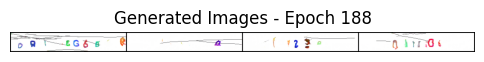

[188/200][0/157]	Loss_D: 0.6421	Loss_G: 1.6536	D(x): 0.8825	D(G(z)): 0.3524 / 0.2561
[188/200][50/157]	Loss_D: 0.6245	Loss_G: 3.0552	D(x): 0.9389	D(G(z)): 0.3849 / 0.0797
[188/200][100/157]	Loss_D: 0.6204	Loss_G: 2.9573	D(x): 0.8238	D(G(z)): 0.3078 / 0.0802
[188/200][150/157]	Loss_D: 0.9637	Loss_G: 1.5589	D(x): 0.8400	D(G(z)): 0.4725 / 0.2716


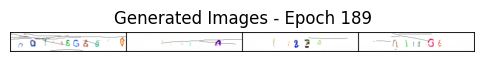

[189/200][0/157]	Loss_D: 1.0060	Loss_G: 2.8556	D(x): 0.9146	D(G(z)): 0.5556 / 0.0858
[189/200][50/157]	Loss_D: 0.4379	Loss_G: 2.0210	D(x): 0.8736	D(G(z)): 0.2359 / 0.1855
[189/200][100/157]	Loss_D: 0.6056	Loss_G: 2.5499	D(x): 0.9176	D(G(z)): 0.3634 / 0.1189
[189/200][150/157]	Loss_D: 1.3749	Loss_G: 1.0029	D(x): 0.3448	D(G(z)): 0.0318 / 0.4214


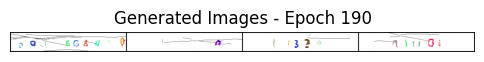

[190/200][0/157]	Loss_D: 0.8914	Loss_G: 3.2584	D(x): 0.9539	D(G(z)): 0.5119 / 0.0585
[190/200][50/157]	Loss_D: 0.4722	Loss_G: 1.5554	D(x): 0.7752	D(G(z)): 0.1682 / 0.2574
[190/200][100/157]	Loss_D: 0.8304	Loss_G: 1.0935	D(x): 0.5278	D(G(z)): 0.0634 / 0.4001
[190/200][150/157]	Loss_D: 0.5949	Loss_G: 1.4253	D(x): 0.7865	D(G(z)): 0.2522 / 0.3252


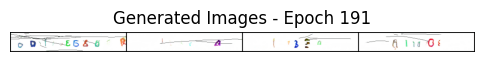

[191/200][0/157]	Loss_D: 0.4589	Loss_G: 2.3179	D(x): 0.8824	D(G(z)): 0.2547 / 0.1383
[191/200][50/157]	Loss_D: 0.9825	Loss_G: 2.4529	D(x): 0.8876	D(G(z)): 0.5016 / 0.1382
[191/200][100/157]	Loss_D: 0.3653	Loss_G: 1.7100	D(x): 0.8380	D(G(z)): 0.1514 / 0.2717
[191/200][150/157]	Loss_D: 0.4288	Loss_G: 2.3413	D(x): 0.8359	D(G(z)): 0.2015 / 0.1542


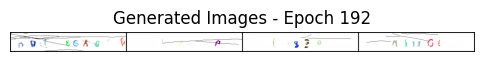

[192/200][0/157]	Loss_D: 0.4848	Loss_G: 2.5609	D(x): 0.9186	D(G(z)): 0.2967 / 0.1170
[192/200][50/157]	Loss_D: 0.9268	Loss_G: 0.9539	D(x): 0.5109	D(G(z)): 0.1068 / 0.4719
[192/200][100/157]	Loss_D: 0.5094	Loss_G: 1.3972	D(x): 0.6916	D(G(z)): 0.0946 / 0.3798
[192/200][150/157]	Loss_D: 0.3927	Loss_G: 2.6612	D(x): 0.8528	D(G(z)): 0.1712 / 0.1060


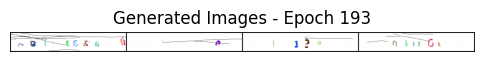

[193/200][0/157]	Loss_D: 0.5276	Loss_G: 2.9144	D(x): 0.9176	D(G(z)): 0.3173 / 0.0845
[193/200][50/157]	Loss_D: 0.7141	Loss_G: 0.9943	D(x): 0.6159	D(G(z)): 0.1198 / 0.4280
[193/200][100/157]	Loss_D: 0.5016	Loss_G: 2.2373	D(x): 0.7809	D(G(z)): 0.1987 / 0.1410
[193/200][150/157]	Loss_D: 0.4701	Loss_G: 2.3106	D(x): 0.9363	D(G(z)): 0.3027 / 0.1387


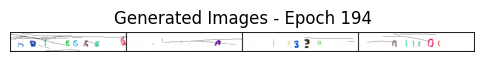

[194/200][0/157]	Loss_D: 1.3843	Loss_G: 3.5627	D(x): 0.9819	D(G(z)): 0.6561 / 0.0484
[194/200][50/157]	Loss_D: 0.4879	Loss_G: 2.1378	D(x): 0.8730	D(G(z)): 0.2692 / 0.1578
[194/200][100/157]	Loss_D: 0.6462	Loss_G: 2.4206	D(x): 0.9446	D(G(z)): 0.3994 / 0.1203
[194/200][150/157]	Loss_D: 0.5076	Loss_G: 2.6903	D(x): 0.7939	D(G(z)): 0.2056 / 0.1182


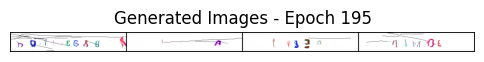

[195/200][0/157]	Loss_D: 0.9356	Loss_G: 4.3295	D(x): 0.9674	D(G(z)): 0.5091 / 0.0199
[195/200][50/157]	Loss_D: 0.6354	Loss_G: 1.0685	D(x): 0.6841	D(G(z)): 0.1684 / 0.4104
[195/200][100/157]	Loss_D: 0.4224	Loss_G: 2.4398	D(x): 0.8760	D(G(z)): 0.2328 / 0.1356
[195/200][150/157]	Loss_D: 0.5332	Loss_G: 2.1529	D(x): 0.7067	D(G(z)): 0.1298 / 0.1820


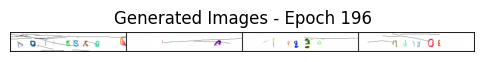

[196/200][0/157]	Loss_D: 0.4733	Loss_G: 1.2155	D(x): 0.7280	D(G(z)): 0.1011 / 0.3969
[196/200][50/157]	Loss_D: 0.5198	Loss_G: 1.7965	D(x): 0.7440	D(G(z)): 0.1441 / 0.2259
[196/200][100/157]	Loss_D: 0.4369	Loss_G: 3.2172	D(x): 0.8525	D(G(z)): 0.2119 / 0.0718
[196/200][150/157]	Loss_D: 3.4999	Loss_G: 4.3661	D(x): 0.9975	D(G(z)): 0.9407 / 0.0518


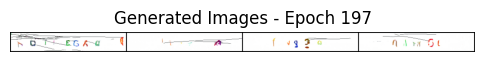

[197/200][0/157]	Loss_D: 1.2380	Loss_G: 4.1422	D(x): 0.9013	D(G(z)): 0.5956 / 0.0322
[197/200][50/157]	Loss_D: 0.4472	Loss_G: 1.7491	D(x): 0.7709	D(G(z)): 0.1420 / 0.2341
[197/200][100/157]	Loss_D: 0.5900	Loss_G: 2.3835	D(x): 0.8379	D(G(z)): 0.3061 / 0.1340
[197/200][150/157]	Loss_D: 0.7322	Loss_G: 0.9349	D(x): 0.5697	D(G(z)): 0.0735 / 0.4618


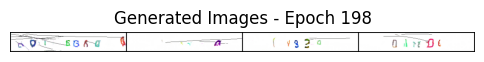

[198/200][0/157]	Loss_D: 0.3423	Loss_G: 2.3526	D(x): 0.8357	D(G(z)): 0.1222 / 0.1322
[198/200][50/157]	Loss_D: 0.5111	Loss_G: 1.7481	D(x): 0.7808	D(G(z)): 0.1893 / 0.2356
[198/200][100/157]	Loss_D: 0.7516	Loss_G: 1.0574	D(x): 0.5540	D(G(z)): 0.0682 / 0.4252
[198/200][150/157]	Loss_D: 0.5895	Loss_G: 1.3670	D(x): 0.6361	D(G(z)): 0.0743 / 0.3183


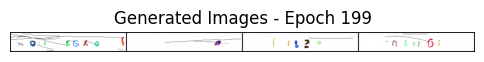

[199/200][0/157]	Loss_D: 0.9304	Loss_G: 4.6321	D(x): 0.9780	D(G(z)): 0.5313 / 0.0163
[199/200][50/157]	Loss_D: 0.5067	Loss_G: 1.6557	D(x): 0.8061	D(G(z)): 0.2175 / 0.2512
[199/200][100/157]	Loss_D: 0.4183	Loss_G: 2.9540	D(x): 0.8530	D(G(z)): 0.1848 / 0.0762
[199/200][150/157]	Loss_D: 0.4353	Loss_G: 1.3888	D(x): 0.8359	D(G(z)): 0.2018 / 0.3148


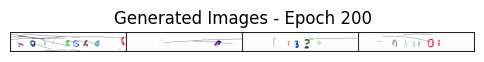

In [13]:
# Training Loop
# Number of training epochs
num_epochs = 200

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        for _ in range(2): #double update
            netG.zero_grad()
            label.fill_(real_label)  # fake labels are real for generator cost
            # Since we just updated D, perform another forward pass of all-fake batch through D
            # Generate new fake images
            noise = torch.randn(b_size, nz, 1, 1, device=device)
            fake = netG(noise)
            output = netD(fake).view(-1)
            # Calculate G's loss based on this output
            errG = criterion(output, label)
            # Calculate gradients for G
            errG.backward()
            D_G_z2 = output.mean().item()
            # Update G
            optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

    # --- Display a generated image after each epoch ---
    with torch.no_grad():
        fake_sample = netG(fixed_noise).detach().cpu()
    plt.figure(figsize=(6,6))
    plt.axis("off")
    plt.title(f"Generated Images - Epoch {epoch+1}")
    plt.imshow(np.transpose(vutils.make_grid(fake_sample[:4], padding=2, normalize=True), (1,2,0)))
    plt.show()

### Plot Training Generator and Discriminator loss

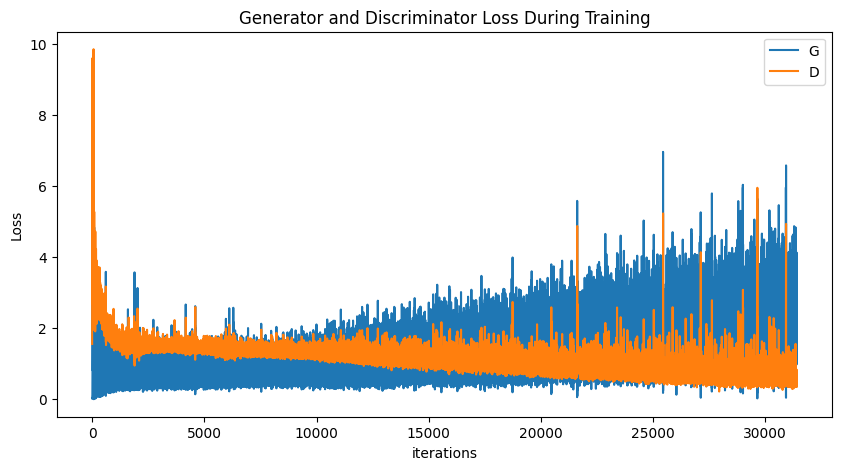

In [14]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

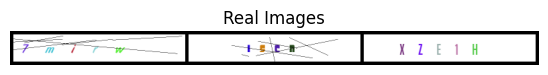

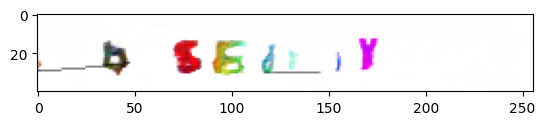

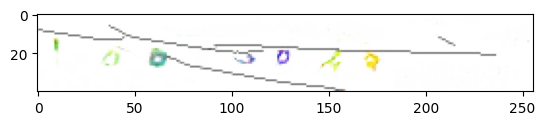

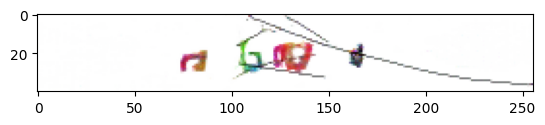

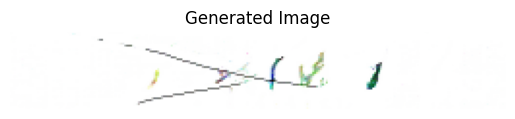

In [19]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:3], padding=5, normalize=True).cpu(),(1,2,0)))
plt.show()

def generate_fake_image():
    # Make sure the generator is in eval mode
    netG.eval()
    
    # Generate a single latent vector
    noise = torch.randn(1, nz, 1, 1, device=device)
    
    # Generate fake image
    with torch.no_grad():
        fake_img = netG(noise).cpu()  # shape: [1, C, H, W]
    
    # Convert to numpy for plotting
    img = fake_img[0]  # remove batch dimension
    np_img = np.transpose(img, (1, 2, 0))  # [H, W, C]
    
    # Rescale from [-1,1] -> [0,1] for display
    np_img = (np_img + 1) / 2.0
    
    # If grayscale, remove channel dimension
    if np_img.shape[2] == 1:
        np_img = np_img[:, :, 0]
        plt.imshow(np_img, cmap='gray')
    else:
        plt.imshow(np_img)
    
    plt.axis('off')
    plt.title("Generated Image")
    plt.show()

for i in range(3):
    noise = torch.randn(1, nz, 1, 1, device=device)
    fake = netG(noise).detach().cpu()
    plt.imshow(np.transpose((fake[0] + 1)/2, (1,2,0)))
    plt.show()

generate_fake_image()

In [21]:
# Save Generator weights
torch.save(netG.state_dict(), "generator.pth")

# Save Discriminator weights
torch.save(netD.state_dict(), "discriminator.pth")